# Exploring All Oakland Business Data: Business Licenses, Data Axle, and D&B

This notebook supersedes `explore_axle_licenses.ipynb`. It is a **self-contained** three-source
audit of everything currently known about Oakland business data, extending the earlier
Business-License (BL) vs. Data-Axle (DA) comparison to include the new **Dun & Bradstreet (D&B)**
delivery.

The goal is *not* to produce a merged database. It is to learn enough about what each source
represents -- and how well they can be reconciled -- to design that merge defensibly in a future
notebook. Central question:

> **What does each of BL, Data Axle, and D&B represent, where do they agree or disagree, what
> unique information does each contribute, and what matching/inclusion strategy should eventually
> be used to construct a canonical Oakland business database?**

No source is treated as ground truth. Findings are kept explicitly separate from assumptions and
tentative classifications throughout. Nothing is saved to disk -- all tables, maps, and figures
live only in this notebook.


In [1]:
import io
import re
import warnings
import zipfile

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point
from tqdm.notebook import tqdm

try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except ImportError:
    HAS_RAPIDFUZZ = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.facecolor"] = "white"
tqdm.pandas()


In [2]:
# ---- source files -------------------------------------------------------------------
BL_PATH = "../../data/business/Business License Corridors_050825.xlsx"
DA_PATH = "../../data/business/Oakland_DataAxleV2.xlsx"
DNB_ZIP_PATH = "../../data/business/D&B.zip"
DNB_FILENAMES = {
    2019: "D&B/Alameda_SMAD_2019_Output_JUN2026.xlsx",
    2023: "D&B/Alameda_SMAD_2023_Output_JUN2026.xlsx",
    2025: "D&B/Alameda_SMAD_2025_Output_JUN2026.xlsx",
}
DNB_AUDIT_FILENAMES = {
    2019: "D&B/Alameda_SMAD_Audit_201901.xlsx",
    2023: "D&B/Alameda_SMAD_Audit_202301.xlsx",
    2025: "D&B/Alameda_SMAD_Audit_202501.xlsx",
}
DNB_DICT_FILENAME = "D&B/Alameda_SMAD_Data Dictionary.xlsx"
DNB_YEARS = [2019, 2023, 2025]

BID_PATH = "../../data/corridors/OAK_BIDs/OAK_BIDs.shp"
PP_PATH = "../../data/corridors/Policy_Polygons/Policy_Polygons.shp"
OAKLAND_BOUNDARY_PATH = "../../data/geo/OaklandCityLimits/OaklandCityLimits.shp"

# ---- the subset of Data Axle's ~380 columns that matter for this project ----
DA_RELEVANT_COLS = [
    "Company Name", "Address", "City", "State", "ZIP Code", "Neighborhood",
    "Latitude", "Longitude",
    "Primary NAICS", "Primary NAICS Description",
    "Primary SIC Code", "Primary SIC Description",
    "Location Type", "Type of Business", "Home Business",
    "Location Employee Size Range", "Location Employee Size Actual",
    "Location Sales Volume Range", "Location Sales Volume Actual",
    "Year Established", "Years In Database",
    "Franchise Description 1", "Affiliated Records", "Affiliated Locations",
    "Square Footage", "Credit Score Alpha", "Phone Number Combined",
    "Own or Lease", "Firm or Individual", "Government Office",
]

# ---- rough Oakland geographic extent, used only to flag likely bad geocodes ----
OAK_LAT_RANGE = (37.60, 37.90)
OAK_LON_RANGE = (-122.36, -122.10)
MAP_XLIM = (-122.355, -122.105)
MAP_YLIM = (37.695, 37.86)

# ---- local projected CRS for distance calculations (NAD83 / UTM zone 10N, meters) ----
LOCAL_CRS = "EPSG:26910"
GEO_CRS = "EPSG:4326"

# ---- broad-sector grouping, keyed on the first 2 digits of a NAICS code ----
NAICS2_TO_SECTOR = {
    "11": "Other / Unclassified", "21": "Other / Unclassified", "22": "Other / Unclassified",
    "23": "Construction",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation & Warehousing", "49": "Transportation & Warehousing",
    "51": "Other / Unclassified",
    "52": "Finance, Insurance & Real Estate", "53": "Finance, Insurance & Real Estate",
    "54": "Professional, Scientific & Technical Services",
    "55": "Other / Unclassified",
    "56": "Administrative & Support Services",
    "61": "Education",
    "62": "Health Care & Social Assistance",
    "71": "Arts, Entertainment & Recreation",
    "72": "Accommodation & Food Services",
    "81": "Other Services",
    "92": "Public / Institutional",
    "99": "Other / Unclassified",
}
SECTOR_ORDER = [
    "Retail Trade", "Accommodation & Food Services", "Health Care & Social Assistance",
    "Professional, Scientific & Technical Services", "Finance, Insurance & Real Estate",
    "Construction", "Manufacturing", "Transportation & Warehousing", "Wholesale Trade",
    "Administrative & Support Services", "Education", "Arts, Entertainment & Recreation",
    "Other Services", "Public / Institutional", "Other / Unclassified",
]

# ---- street-address normalization tables ----
STREET_SUFFIX_MAP = {
    "STREET": "ST", "AVENUE": "AVE", "BOULEVARD": "BLVD", "DRIVE": "DR", "ROAD": "RD",
    "LANE": "LN", "PLACE": "PL", "COURT": "CT", "CIRCLE": "CIR", "TERRACE": "TER",
    "PARKWAY": "PKWY", "HIGHWAY": "HWY", "SQUARE": "SQ", "TRAIL": "TRL", "WAY": "WAY",
    "ALLEY": "ALY",
}
DIRECTION_MAP = {"NORTH": "N", "SOUTH": "S", "EAST": "E", "WEST": "W"}
UNIT_MARKER_TOKENS = {
    "#", "STE", "SUITE", "UNIT", "APT", "BLDG", "BUILDING", "NO", "RM", "ROOM", "FL",
    "FLOOR", "PMB",
}
STREET_SUFFIX_TOKENS = set(STREET_SUFFIX_MAP.values())

# ---- proximity thresholds (meters) used throughout the matching sections ----
DISTANCE_THRESHOLDS_M = [10, 25, 50, 100]

RNG_SEED = 42


## 1. Re-establish the BL and Data Axle Baseline

Before bringing D&B into the picture, we recompute (not hard-code) the core facts about BL and DA
from the earlier notebook, concisely. This keeps the new notebook self-contained and gives us a
fixed baseline to compare D&B against.


In [3]:
bl_raw = pd.read_excel(BL_PATH)
da_raw = pd.read_excel(DA_PATH)
da = da_raw[DA_RELEVANT_COLS].copy()
print("BL raw shape:", bl_raw.shape)
print("DA raw shape:", da_raw.shape, "-> trimmed working frame:", da.shape)
bl_raw.head(3)


BL raw shape: (46514, 6)
DA raw shape: (29545, 383) -> trimmed working frame: (29545, 30)


,Bus address,"Bus City, State",NAICS6D,NAICS6D_Desc,LON,LAT
0,3775 ALAMEDA AVE STE B,"OAKLAND, CA 94601-3921",484110.0,"General Freight Trucking, Local",-122.223323,37.768064
1,7201 EARHART RD,"OAKLAND, CA 94621-4507",492110.0,Couriers,-122.216631,37.736097
2,1707 WOOD ST,"OAKLAND, CA 94607-1623",485999.0,All Other Transit and Ground Passenger Transportation,-122.295654,37.816101


In [4]:
def normalize_address(addr):
    """Uppercase, trim, and normalize punctuation / whitespace / common street words."""
    if pd.isna(addr):
        return np.nan
    s = str(addr).upper().replace(".", "").replace(",", " ")
    s = re.sub(r"#\s*", "# ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [DIRECTION_MAP.get(t, t) for t in s.split(" ")]
    tokens = [STREET_SUFFIX_MAP.get(t, t) for t in tokens]
    return " ".join(tokens).strip()


def split_unit(addr_norm):
    """Split a normalized address into (base_address, unit), by marker token or trailing suffix."""
    if pd.isna(addr_norm):
        return np.nan, np.nan
    tokens = addr_norm.split(" ")
    marker_idx = next((i for i, t in enumerate(tokens) if t in UNIT_MARKER_TOKENS), None)
    if marker_idx is not None and marker_idx < len(tokens) - 1:
        base, unit_tokens = " ".join(tokens[:marker_idx]), tokens[marker_idx + 1:]
    else:
        suffix_idx = max((i for i, t in enumerate(tokens) if t in STREET_SUFFIX_TOKENS), default=None)
        if suffix_idx is not None and suffix_idx < len(tokens) - 1:
            base, unit_tokens = " ".join(tokens[:suffix_idx + 1]), tokens[suffix_idx + 1:]
        else:
            return addr_norm, np.nan
    unit = " ".join(unit_tokens).strip() or np.nan
    return (base.strip() or addr_norm), unit


def naics_to_sector(naics_code):
    if pd.isna(naics_code):
        return "Other / Unclassified"
    return NAICS2_TO_SECTOR.get(str(naics_code)[:2], "Other / Unclassified")


bl_std = bl_raw.copy()
bl_std["address_norm"] = bl_std["Bus address"].apply(normalize_address)
bl_std[["address_base", "address_unit"]] = bl_std["address_norm"].apply(lambda a: pd.Series(split_unit(a)))
bl_std["zip5"] = bl_std["Bus City, State"].str.extract(r"(\d{5})")
bl_std["lat_std"], bl_std["lon_std"] = bl_std["LAT"], bl_std["LON"]
bl_std["naics_code_std"] = bl_std["NAICS6D"].dropna().astype("int64").astype(str)
bl_std["sector"] = bl_std["NAICS6D"].apply(naics_to_sector)

da_std = da.copy()
da_std["address_norm"] = da_std["Address"].apply(normalize_address)
da_std[["address_base", "address_unit"]] = da_std["address_norm"].apply(lambda a: pd.Series(split_unit(a)))
da_std["zip5"] = da_std["ZIP Code"].astype(str).str.extract(r"(\d{5})")
da_std["lat_std"], da_std["lon_std"] = da_std["Latitude"], da_std["Longitude"]
da_std["naics_code_std"] = da_std["Primary NAICS"].dropna().astype("int64").astype(str)
da_std["sector"] = da_std["Primary NAICS"].apply(naics_to_sector)

print("bl_std, da_std built:", bl_std.shape, da_std.shape)


bl_std, da_std built: (46514, 14) (29545, 38)


In [5]:
def audit_row(name, df, addr_col, base_col, lat_col, lon_col, naics_col, name_col=None):
    n = len(df)
    coords_present = df[lat_col].notna() & df[lon_col].notna()
    row = {
        "n_records": n,
        "n_unique_raw_address": df[addr_col].nunique(),
        "n_unique_base_address": df[base_col].nunique(),
        "pct_coords_present": round(coords_present.mean() * 100, 1),
        "pct_naics_present": round(df[naics_col].notna().mean() * 100, 1),
        "n_unique_naics": df[naics_col].nunique(),
        "records_per_base_address": round(n / df[base_col].nunique(), 2),
    }
    if name_col is not None:
        row["pct_name_present"] = round(df[name_col].notna().mean() * 100, 1)
    return row

bl_audit = audit_row("BL", bl_std, "Bus address", "address_base", "lat_std", "lon_std", "naics_code_std")
da_audit = audit_row("DA", da_std, "Address", "address_base", "lat_std", "lon_std", "naics_code_std", "Company Name")
audit_summary = pd.DataFrame({"BL": bl_audit, "DA": da_audit})
audit_summary


,BL,DA
n_records,46514.00,29545.00
n_unique_raw_address,40398.00,15161.00
n_unique_base_address,33513.00,10599.00
pct_coords_present,98.80,100.00
pct_naics_present,91.50,100.00
n_unique_naics,569.00,2076.00
records_per_base_address,1.39,2.79
pct_name_present,NaN,100.00


**Note:** BL has no business-name field at all (confirmed in the raw column list above -- `Bus
address`, `Bus City, State`, `NAICS6D`, `NAICS6D_Desc`, `LON`, `LAT` only), so `pct_name_present`
is left blank for BL rather than fabricated.


In [6]:
bl_home_equiv = np.nan  # BL has no home-business equivalent -- explicit, not inferred
print("DA 'Home Business' distribution:")
print(da_std["Home Business"].value_counts(dropna=False))
print()
print(f"DA home-based share: {da_std['Home Business'].eq('Yes').mean()*100:.1f}%")
print(f"BL home-based share: not identifiable from this extract (no equivalent field)")


DA 'Home Business' distribution:
Home Business
No     26709
Yes     2836
Name: count, dtype: int64

DA home-based share: 9.6%
BL home-based share: not identifiable from this extract (no equivalent field)


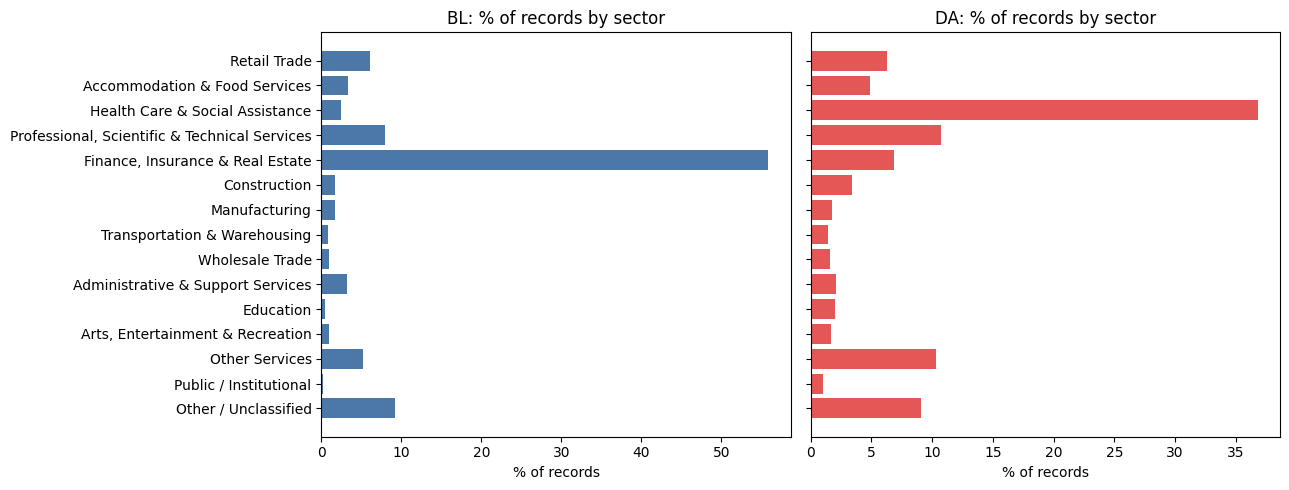

,bl_count,da_count,bl_pct,da_pct
sector,,,,
Retail Trade,2854,1858,6.1,6.3
Accommodation & Food Services,1553,1456,3.3,4.9
Health Care & Social Assistance,1163,10866,2.5,36.8
"Professional, Scientific & Technical Services",3680,3159,7.9,10.7
"Finance, Insurance & Real Estate",25990,2034,55.9,6.9
Construction,777,1010,1.7,3.4
Manufacturing,785,529,1.7,1.8
Transportation & Warehousing,351,408,0.8,1.4
Wholesale Trade,433,459,0.9,1.6


In [7]:
sector_counts = pd.DataFrame({
    "bl_count": bl_std["sector"].value_counts(),
    "da_count": da_std["sector"].value_counts(),
}).reindex(SECTOR_ORDER).fillna(0).astype(int)
sector_counts["bl_pct"] = (sector_counts["bl_count"] / sector_counts["bl_count"].sum() * 100).round(1)
sector_counts["da_pct"] = (sector_counts["da_count"] / sector_counts["da_count"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].barh(SECTOR_ORDER, sector_counts["bl_pct"], color="#4C78A8")
axes[0].set_title("BL: % of records by sector"); axes[0].invert_yaxis(); axes[0].set_xlabel("% of records")
axes[1].barh(SECTOR_ORDER, sector_counts["da_pct"], color="#E45756")
axes[1].set_title("DA: % of records by sector"); axes[1].set_xlabel("% of records")
plt.tight_layout()
plt.show()
sector_counts


In [8]:
da_addr_counts = da_std["address_base"].value_counts()
bl_addr_counts = bl_std["address_base"].value_counts()
high_count_da_addrs = da_addr_counts[da_addr_counts >= 5].index
at_high_count = da_std["address_base"].isin(high_count_da_addrs)

print(f"BL records per base address -- mean {bl_addr_counts.mean():.2f}, median {bl_addr_counts.median():.0f}, max {bl_addr_counts.max()}")
print(f"DA records per base address -- mean {da_addr_counts.mean():.2f}, median {da_addr_counts.median():.0f}, max {da_addr_counts.max()}")
print()
print(f"DA addresses with >=5 records: {len(high_count_da_addrs):,} addresses, "
      f"covering {at_high_count.sum():,} records ({at_high_count.mean()*100:.1f}% of all DA records)")
print("Sector mix at those high-count addresses vs. DA overall:")
print(pd.DataFrame({
    "high_count_addr_pct": (da_std.loc[at_high_count, "sector"].value_counts(normalize=True) * 100).round(1),
    "da_overall_pct": sector_counts["da_pct"],
}).sort_values("high_count_addr_pct", ascending=False).head(5))


BL records per base address -- mean 1.39, median 1, max 160
DA records per base address -- mean 2.74, median 1, max 713

DA addresses with >=5 records: 719 addresses, covering 15,916 records (53.9% of all DA records)
Sector mix at those high-count addresses vs. DA overall:
                                               high_count_addr_pct  da_overall_pct
sector                                                                            
Health Care & Social Assistance                               59.4            36.8
Professional, Scientific & Technical Services                 10.5            10.7
Other / Unclassified                                           5.8             9.1
Finance, Insurance & Real Estate                               5.6             6.9
Other Services                                                 5.3            10.3


**Takeaway (baseline, recomputed):**

- BL (~46.5k records) has roughly **1 record per base address**, while DA (~29.5k records) runs
  much higher, and that concentration is driven overwhelmingly by **Health Care & Social
  Assistance** -- addresses with 5+ DA records skew far more toward Health Care than DA overall,
  consistent with medical buildings listing every individual practitioner as a separate DA record.
- BL's sector distribution is dominated by **Finance, Insurance & Real Estate** (mostly
  rental-property registrations, not storefronts), a very different profile from DA's health-care
  concentration -- the two sources are not describing the same thing.
- BL has **no business name** and **no home-business flag** at all; DA has both. This asymmetry
  matters a great deal once D&B is added, because D&B (Section 5) turns out to share BL's
  name/address gap rather than DA's richness.
- These confirm the prior notebook's framing: BL is closer to *"one licensed use at one address"*,
  DA is closer to *"one establishment/practitioner, individually listed."*


## 2. Inspect the D&B Delivery and Data Dictionary

The D&B delivery arrives as `D&B.zip` (three yearly SMAD "Output" workbooks, three matching
"Audit" workbooks, and a data dictionary). We read everything **directly out of the zip archive
into memory** -- nothing is extracted to disk.


In [9]:
zf = zipfile.ZipFile(DNB_ZIP_PATH)
print("Files inside D&B.zip:")
for n in zf.namelist():
    print(" ", n)


Files inside D&B.zip:
  D&B/
  D&B/Alameda_SMAD_Audit_201901.xlsx
  D&B/Alameda_SMAD_Audit_202301.xlsx
  D&B/Alameda_SMAD_Audit_202501.xlsx
  D&B/Alameda_SMAD_Data Dictionary.xlsx
  D&B/D&B SafeTransPort -- Customer ID _ alamedac - File Alameda_SMAD_2019_Output_JUN2026.xlsx.zip Ready for Pickup.eml
  D&B/D&B SafeTransPort -- Customer ID _ alamedac - File Alameda_SMAD_2023_Output_JUN2026.xlsx.zip Ready for Pickup.eml
  D&B/D&B SafeTransPort -- Customer ID _ alamedac - File Alameda_SMAD_2025_Output_JUN2026.xlsx.zip Ready for Pickup.eml
  D&B/Alameda_SMAD_2019_Output_JUN2026.xlsx
  D&B/Alameda_SMAD_2023_Output_JUN2026.xlsx
  D&B/Alameda_SMAD_2025_Output_JUN2026.xlsx


In [10]:
def read_dnb_excel(inner_path, **kwargs):
    return pd.read_excel(io.BytesIO(zf.read(inner_path)), **kwargs)

dnb_raw = {yr: read_dnb_excel(fn) for yr, fn in DNB_FILENAMES.items()}
dnb_audit = {yr: read_dnb_excel(fn, header=None) for yr, fn in DNB_AUDIT_FILENAMES.items()}

for yr, df in dnb_raw.items():
    print(f"{yr}: shape={df.shape}")
print()
print("Column lists identical across all 3 years:",
      dnb_raw[2019].columns.tolist() == dnb_raw[2023].columns.tolist() == dnb_raw[2025].columns.tolist())


2019: shape=(1060, 184)
2023: shape=(1736, 184)
2025: shape=(177, 184)

Column lists identical across all 3 years: True


In [11]:
# BASECAT (and a whole cluster of other fields, see Section 3) is populated only for DUNS that
# received an actual appended D&B report -- everything else is a bare DUNS number. We call that
# boolean `has_report` and use it throughout.
for yr, df in dnb_raw.items():
    df["has_report"] = df["BASECAT"].notna()

delivery_comparison = pd.DataFrame({
    yr: {
        "n_rows (DUNS submitted)": len(df),
        "n_unique_DUNS": df["DUNS"].nunique(),
        "n_duplicate_DUNS": df["DUNS"].duplicated().sum(),
        "n_with_report": int(df["has_report"].sum()),
        "pct_with_report": round(df["has_report"].mean() * 100, 1),
        "n_columns": df.shape[1] - 1,  # exclude the has_report flag we just added
    }
    for yr, df in dnb_raw.items()
})
delivery_comparison


,2019,2023,2025
n_rows (DUNS submitted),1060.0,1736.0,177.0
n_unique_DUNS,1060.0,1736.0,177.0
n_duplicate_DUNS,0.0,0.0,0.0
n_with_report,263.0,1717.0,176.0
pct_with_report,24.8,98.9,99.4
n_columns,184.0,184.0,184.0


**Takeaway:** the three delivered files are **very different sizes** (1,060 / 1,736 / 177 rows) and,
as the next cell shows, most of that size difference is not "real" business coverage -- it is the
share of rows that carry an actual appended report vs. a bare DUNS number. We treat this as a
finding to be explained (Section 3), not a fact to build on yet.


In [12]:
# ---- human-readable reference table built from the actual data dictionary ------------------
dict_raw = read_dnb_excel(DNB_DICT_FILENAME, header=None)
dict_raw.columns = ["start", "end", "length", "fmt", "varname", "field", "description"]
dict_raw = dict_raw.iloc[4:].reset_index(drop=True)  # skip title/blank/header rows

# Layout: a row with a non-null varname starts a field; following varname-null rows are its
# coded-value legend (e.g. "M = Moved", "Blank = Not Moved"), spread across extra rows.
dnb_dictionary = {}
current = None
for _, row in dict_raw.iterrows():
    if pd.notna(row["varname"]):
        if current is not None:
            dnb_dictionary[current["varname"]] = current
        current = {"varname": row["varname"], "field": row["field"],
                    "description": str(row["description"]) if pd.notna(row["description"]) else "",
                    "codes": []}
    elif current is not None and pd.notna(row["description"]):
        current["codes"].append(str(row["description"]))
if current is not None:
    dnb_dictionary[current["varname"]] = current

print(f"parsed {len(dnb_dictionary)} field definitions from the data dictionary "
      f"(not printing all {len(dnb_dictionary)} -- only the subset relevant to this project below)")


parsed 184 field definitions from the data dictionary (not printing all 184 -- only the subset relevant to this project below)


In [13]:
FIELDS_OF_INTEREST = [
    "DUNS", "ARCH_DTE", "BASE_DAT", "D1STBASE", "BASECAT", "TRANS_CD", "REC_TYPE",
    "STATUS", "OB_IND", "STOP_IND", "MOVED", "YRSTART", "OWNS",
    "SALES", "SALES_CD", "EMPTOTL", "EMPHERE", "NBR_SICS", "SIC10",
    "ZIP5", "CITY_CD", "STATE", "LATITUDE", "LONGITUD", "GEO_ACC",
    "ULTDUNSD", "HDQ_DUNS", "PAR_DUNS", "FAMILY",
    "HL_NAME", "HL_ADDR",
    "RATING", "ORATING", "CONDITN", "FINANCE", "WORTH", "PRESCRN",
]

field_reference = pd.DataFrame([
    {
        "variable": v,
        "field_label": dnb_dictionary[v]["field"],
        "description": dnb_dictionary[v]["description"][:160],
        "codes": " | ".join(dnb_dictionary[v]["codes"])[:160],
    }
    for v in FIELDS_OF_INTEREST if v in dnb_dictionary
])
field_reference


,variable,field_label,description,codes
0,DUNS,D-U-N-S® Number,The Data Universal Numbering System (D-U-N-S®). Non-indicative globally recognized special nine-digit number created...,
1,ARCH_DTE,Date of File Creation,The archive date SMAD was created. The first archive month for SMAD is March 2003.,
2,BASE_DAT,Date Of Last Revision,The date associated with the last full report revision.,
3,D1STBASE,First Date Data appeared on Database,The date associated with the first full report,
4,BASECAT,Record Type,Code that indicate the type of record stored on the file for that given business.,R = Full | B = Branch | S = D-U-N-S® Support
5,TRANS_CD,Transaction Code,Identifies last transaction processed against the master D&B record for this location. Used with D&B clients receivi...,1 = record was deleted from master file | 2 = record was added to master file | 3 = information was changed in this ...
6,REC_TYPE,Record Class,Code indicating the nature of the record.,0 = All Full reports and Branches with BOTH a valid SIC (non-9999) and telephone number. | 1 = All Duns Support Reco...
7,STATUS,Status Indicator,Code indicating the organizational status of this establishment:,S = Single Location | H = Headquarters | B = Branch
8,OB_IND,Out of Business Indicator,"A record as a result of an investigation, has been determined that the company has gone out of business or has been ...",0 = Not Out of Business | 1 = Out of Business
9,STOP_IND,Case on Stop Distribution,Code indicating the business is under investigation due to possible invalid data.,0 = Not on Stop | 1 = Stop


**Takeaway on `HL_NAME` / `HL_ADDR`:** per the dictionary, these are **Hot List change-indicator
flags** (`HL_NAME` = "Company Name Change Indicator", coded `6`/blank; `HL_ADDR` = "Address Change
Indicator", coded `7`/blank) -- **not** the establishment's actual name or address. This directly
confirms one of the most consequential findings of this notebook (Section 5): the abbreviation
alone would have suggested a name/address field, and the dictionary is what reveals it is not one.


## 3. What Do the D&B Yearly Files Actually Represent?

This is the most important methodological question about D&B in this notebook. The row counts
(1,060 / 1,736 / 177) vary far too much to be three snapshots of the same stable business universe.
Before doing anything else with D&B, we test what kind of file this actually is: a full annual
census, an archive of changed/added records, active+inactive businesses, a filtered extract, or
something else.


In [14]:
status_fields = ["BASECAT", "TRANS_CD", "REC_TYPE", "STATUS", "OB_IND", "STOP_IND", "MOVED", "IN_DATE"]
for yr, df in dnb_raw.items():
    print(f"=== {yr} (n={len(df)}, has_report={df['has_report'].sum()}) ===")
    for f in status_fields:
        print(f"  {f}: {df[f].value_counts(dropna=False).to_dict()}")
    print()


=== 2019 (n=1060, has_report=263) ===
  BASECAT: {nan: 797, 'S': 218, 'R': 39, 'B': 6}
  TRANS_CD: {nan: 797, 3.0: 202, 2.0: 61}
  REC_TYPE: {nan: 797, 1.0: 215, 0.0: 45, 2.0: 3}
  STATUS: {nan: 797, 'S': 256, 'B': 6, 'H': 1}
  OB_IND: {nan: 797, 0.0: 263}
  STOP_IND: {nan: 797, 0.0: 263}
  MOVED: {nan: 1054, 'M': 6}
  IN_DATE: {nan: 797, 'D': 218, 'I': 40, 'T': 5}

=== 2023 (n=1736, has_report=1717) ===
  BASECAT: {'S': 1394, 'R': 292, 'B': 31, nan: 19}
  TRANS_CD: {3.0: 1459, 2.0: 258, nan: 19}
  REC_TYPE: {1.0: 1394, 0.0: 321, nan: 19, 2.0: 2}
  STATUS: {'S': 1676, 'B': 31, nan: 19, 'H': 10}
  OB_IND: {0.0: 1717, nan: 19}
  STOP_IND: {0.0: 1717, nan: 19}
  MOVED: {nan: 1638, 'M': 98}
  IN_DATE: {'D': 1394, 'I': 259, 'T': 64, nan: 19}

=== 2025 (n=177, has_report=176) ===
  BASECAT: {'S': 174, 'B': 1, 'R': 1, nan: 1}
  TRANS_CD: {3.0: 112, 2.0: 64, nan: 1}
  REC_TYPE: {1.0: 174, 0.0: 2, nan: 1}
  STATUS: {'S': 175, 'B': 1, nan: 1}
  OB_IND: {0.0: 176, nan: 1}
  STOP_IND: {0.0: 176, n

**Empirical finding:** `BASECAT`, `TRANS_CD`, `REC_TYPE`, `STATUS`, `OB_IND`, and `STOP_IND` are
either **all simultaneously present or all simultaneously absent** for a given row -- there is no
row with some of these populated and others not. That block of NaNs is exactly `~1 - has_report`
in size. In other words: every row has a `DUNS`, but only the `has_report` subset carries *any*
descriptive, financial, geographic, or status information at all. The rest are bare DUNS numbers
with nothing else on the row.


In [15]:
# Confirm the audit files independently corroborate the same split (PRESENT counts by field).
for yr, raw in dnb_audit.items():
    raw.columns = ["field_name", "field_position", "present", "absent", "non_numeric", "zeros", "out_range"]
    duns_present = raw.loc[raw["field_name"] == "DUNS", "present"].iloc[0]
    archdte_present = raw.loc[raw["field_name"] == "ARCH_DTE", "present"].iloc[0]
    print(f"{yr} audit file: DUNS present={duns_present}, ARCH_DTE present={archdte_present} "
          f"(matches has_report count computed above: {dnb_raw[yr]['has_report'].sum()})")


2019 audit file: DUNS present=1060, ARCH_DTE present=263 (matches has_report count computed above: 263)
2023 audit file: DUNS present=1736, ARCH_DTE present=1717 (matches has_report count computed above: 1717)
2025 audit file: DUNS present=177, ARCH_DTE present=176 (matches has_report count computed above: 176)


In [16]:
# Is the split just "first N rows are the old base file, appended rows are new" (i.e. contiguous
# blocks), or are populated/unpopulated rows interleaved throughout the file?
for yr, df in dnb_raw.items():
    rownum = np.arange(len(df))
    pop_rows = rownum[df["has_report"].values]
    print(f"{yr}: has_report rows span the full file (min={pop_rows.min()}, max={pop_rows.max()} "
          f"of {len(df)-1}), interleaved rather than one contiguous block.")


2019: has_report rows span the full file (min=6, max=1058 of 1059), interleaved rather than one contiguous block.
2023: has_report rows span the full file (min=0, max=1735 of 1735), interleaved rather than one contiguous block.
2025: has_report rows span the full file (min=0, max=176 of 176), interleaved rather than one contiguous block.


**Interpretation (empirical, not assumed):** the file structure -- a full list of DUNS numbers
where only a variable subset actually carries an appended commercial report, interleaved
throughout the file rather than appended as a separate block -- is the signature of a **match/append
delivery against a submitted list of identifiers**, not a full annual census of Alameda County
businesses. D&B appears to have been given (or already held) a list of DUNS numbers for the county
and appended full report data only where a report was available/current; the `has_report`
subset -- not the raw row count -- is the closest thing to "records D&B actually describes" in
each delivery.


In [17]:
d19, d23, d25 = (set(dnb_raw[yr]["DUNS"]) for yr in DNB_YEARS)
print(f"unique DUNS -- 2019: {len(d19):,}  2023: {len(d23):,}  2025: {len(d25):,}")
print(f"pairwise overlap -- 2019&2023: {len(d19 & d23)}   2019&2025: {len(d19 & d25)}   2023&2025: {len(d23 & d25)}")
print(f"all three years:    {len(d19 & d23 & d25)}")
print(f"union across all three years: {len(d19 | d23 | d25):,}")


unique DUNS -- 2019: 1,060  2023: 1,736  2025: 177
pairwise overlap -- 2019&2023: 0   2019&2025: 0   2023&2025: 0
all three years:    0
union across all three years: 2,973


**Empirical finding -- zero DUNS overlap across years.** Not one DUNS number is shared between any
two of the three delivered files, let alone all three. This rules out interpreting the three files
as repeated snapshots of the *same* business (or even the same *candidate list*) re-observed over
time: we cannot track a single DUNS across 2019 -> 2023 -> 2025 in this delivery, because the three
files simply describe disjoint sets of DUNS numbers. Consequently we also **cannot test** whether a
given business's attributes changed between years, or whether an out-of-business flag in one year
persists into the next -- there is no shared unit to compare.


In [18]:
# Does a record marked out-of-business in the has_report subset actually carry that flag, or is
# OB_IND effectively silent in this delivery? (Feeds directly into Section 11.)
for yr, df in dnb_raw.items():
    pop = df[df["has_report"]]
    print(f"{yr}: OB_IND value counts among has_report rows: {pop['OB_IND'].value_counts(dropna=False).to_dict()}")


2019: OB_IND value counts among has_report rows: {0.0: 263}
2023: OB_IND value counts among has_report rows: {0.0: 1717}
2025: OB_IND value counts among has_report rows: {0.0: 176}


> **What can and cannot be inferred longitudinally from these D&B files?**
>
> - **Cannot:** track any individual business across the three archive years -- DUNS numbers do not
>   repeat across 2019/2023/2025 in this delivery, so there is no shared entity to compare.
> - **Cannot:** infer *closure* from a business's absence in a later file. Absence here reflects the
>   disjoint DUNS universes described above, not confirmed business closure -- treating
>   disappearance as closure would be a methodological error given this structure.
> - **Cannot:** treat raw row counts (1,060 / 1,736 / 177) as the number of active Alameda County
>   businesses in that year. The great majority of rows in some years (2019 especially) are bare
>   DUNS stubs with no report at all.
> - **Can:** treat the `has_report` subset within *each* file on its own terms as a cross-sectional
>   sample of businesses D&B held a report for at that archive date, with real (if partial) SIC,
>   geographic, employee, sales, and status information -- this is what the rest of this notebook
>   uses.
> - **Can:** use fields internal to a single record -- like `D1STBASE` (first-appeared date) and
>   `YRSTART` (year business started) -- as a per-record historical signal, since those describe
>   that DUNS's own history in D&B's broader system, independent of whether it recurs in our
>   delivery.


## 4. Geographic Filtering and Oakland Coverage

The delivery is labelled "Alameda" (the county), so we cannot assume every record is in Oakland.
We use the `has_report` subset's coordinates against the actual Oakland municipal boundary
(`OaklandCityLimits.shp`), cross-checked against `ZIP5`, rather than assuming county == city.


In [19]:
def dnb_signed_latlon(df):
    """LATITUDE/LONGITUD are unsigned magnitudes (degrees, implied /1e6) with a separate sign field."""
    lat_sign = df["LAT_SIGN"].map({"+": 1, "-": -1}).fillna(1)
    lon_sign = df["LON_SIGN"].map({"+": 1, "-": -1}).fillna(-1)
    lat = (df["LATITUDE"] / 1e6) * lat_sign
    lon = (df["LONGITUD"] / 1e6) * lon_sign
    return lat, lon

oak_boundary = gpd.read_file(OAKLAND_BOUNDARY_PATH).to_crs(GEO_CRS)
oak_boundary_union = oak_boundary.union_all()
print("Oakland boundary bounds:", oak_boundary_union.bounds)


Oakland boundary bounds: (-122.35584091508454, 37.632072301906405, -122.11480144900551, 37.88537293554305)


In [20]:
dnb_geo_summary = {}
dnb_oak = {}  # Oakland-filtered analytical copies -- dnb_raw is left untouched

for yr, df in dnb_raw.items():
    pop = df[df["has_report"]].copy()
    lat, lon = dnb_signed_latlon(pop)
    valid_coord = lat.between(30, 45) & lon.between(-130, -110)
    pop["lat_std"], pop["lon_std"] = lat, lon

    gdf = gpd.GeoDataFrame(pop[valid_coord], geometry=gpd.points_from_xy(lon[valid_coord], lat[valid_coord]), crs=GEO_CRS)
    in_oak = gdf.within(oak_boundary_union)
    zip_in_oak_range = pop["ZIP5"].between(94601, 94621) | pop["ZIP5"].eq(94604)
    questionable_geo = pop["GEO_ACC"].isin(["Z", "M", "N"]) | pop["GEO_ACC"].isna()

    dnb_geo_summary[yr] = {
        "total_rows": len(df),
        "has_report": len(pop),
        "usable_coords": int(valid_coord.sum()),
        "in_oakland_boundary": int(in_oak.sum()),
        "zip_says_oakland": int(zip_in_oak_range.sum()),
        "outside_oakland": int(valid_coord.sum() - in_oak.sum()),
        "questionable_geocode": int(questionable_geo.sum()),
    }
    dnb_oak[yr] = gdf[in_oak.values].copy()

pd.DataFrame(dnb_geo_summary)


,2019,2023,2025
total_rows,1060,1736,177
has_report,263,1717,176
usable_coords,263,1714,175
in_oakland_boundary,220,1454,154
zip_says_oakland,220,1457,155
outside_oakland,43,260,21
questionable_geocode,3,22,7


In [21]:
# Do the boundary test and the ZIP-based guess roughly agree? (sanity check on the method)
for yr in DNB_YEARS:
    pop = dnb_raw[yr][dnb_raw[yr]["has_report"]]
    lat, lon = dnb_signed_latlon(pop)
    valid = lat.between(30, 45) & lon.between(-130, -110)
    gdf = gpd.GeoDataFrame(pop[valid], geometry=gpd.points_from_xy(lon[valid], lat[valid]), crs=GEO_CRS)
    in_oak = gdf.within(oak_boundary_union)
    zip_guess = pop.loc[valid, "ZIP5"].between(94601, 94621) | pop.loc[valid, "ZIP5"].eq(94604)
    agree = (in_oak.values == zip_guess.values).mean()
    print(f"{yr}: boundary-test vs. ZIP-based guess agree on {agree*100:.1f}% of records")


2019: boundary-test vs. ZIP-based guess agree on 100.0% of records


2023: boundary-test vs. ZIP-based guess agree on 99.8% of records
2025: boundary-test vs. ZIP-based guess agree on 100.0% of records


**Takeaway:** the boundary-polygon test and the simple ZIP-range heuristic agree on **>99%** of
records, which gives confidence in using the boundary test as the primary Oakland filter for the
rest of the notebook. After filtering: **220 (2019) / 1,454 (2023) / 154 (2025)** `has_report`
records fall inside Oakland -- a small number compared to BL (~46.5k) and DA (~29.5k). Every D&B
result below should be read with that small-N caveat in mind. `dnb_oak[year]` (Oakland-only
analytical copies) is used from here on; the full `dnb_raw[year]` frames are left untouched.


## 5. Standardize the Three Sources

We build a common analytical schema -- `source`, `source_record_id`, `business_name`,
`address_original`, `address_normalized`, `address_base`, `unit`, `zip5`, `latitude`, `longitude`,
`industry_code`, `industry_sector` -- while keeping every original column available. BL has no
name; we do not fabricate one. D&B's usable identifier is `DUNS`; whether it also has a usable
name/address field is tested explicitly below rather than assumed from field abbreviations.


In [22]:
bl_entity = pd.DataFrame({
    "source": "BL",
    "source_record_id": bl_std.index.astype(str),
    "business_name": np.nan,  # not present in this BL extract -- explicit, not fabricated
    "address_original": bl_std["Bus address"],
    "address_normalized": bl_std["address_norm"],
    "address_base": bl_std["address_base"],
    "unit": bl_std["address_unit"],
    "zip5": bl_std["zip5"],
    "latitude": bl_std["lat_std"],
    "longitude": bl_std["lon_std"],
    "industry_code": bl_std["naics_code_std"],
    "industry_sector": bl_std["sector"],
})

da_entity = pd.DataFrame({
    "source": "DA",
    "source_record_id": da_std.index.astype(str),
    "business_name": da_std["Company Name"],
    "address_original": da_std["Address"],
    "address_normalized": da_std["address_norm"],
    "address_base": da_std["address_base"],
    "unit": da_std["address_unit"],
    "zip5": da_std["zip5"],
    "latitude": da_std["lat_std"],
    "longitude": da_std["lon_std"],
    "industry_code": da_std["naics_code_std"],
    "industry_sector": da_std["sector"],
})

print("bl_entity:", bl_entity.shape, " da_entity:", da_entity.shape)
da_entity.head(3)


bl_entity: (46514, 12)  da_entity: (29545, 12)


,source,source_record_id,business_name,address_original,address_normalized,address_base,unit,zip5,latitude,longitude,industry_code,industry_sector
0,DA,0,0-90 Health & Human Servicing,7957- Greenly Drive Oakland CA,7957- GREENLY DR OAKLAND CA,7957- GREENLY DR,OAKLAND CA,94605,37.769000,-122.157748,99999004,Other / Unclassified
1,DA,1,1 Seafood & Chicken Restaurant,4014 Macarthur Blvd,4014 MACARTHUR BLVD,4014 MACARTHUR BLVD,NaN,94619,37.790435,-122.197222,44525004,Retail Trade
2,DA,2,10-4 Tow Of Oakland,1409 35th Ave # 94601,1409 35TH AVE # 94601,1409 35TH AVE,94601,94601,37.776516,-122.222874,48841002,Transportation & Warehousing


In [23]:
# Does D&B contain anything resembling a usable establishment name or street address?
# HL_NAME / HL_ADDR were already shown (Section 2) to be Hot-List *change* flags, not values.
# Check every remaining text-like field in the has_report subset for name/address-like content.
sample_pop = pd.concat([dnb_oak[yr] for yr in DNB_YEARS], ignore_index=True)
candidate_text_cols = ["HL_NAME", "HL_ADDR", "LOCATION", "MULTADDR", "CITY_CD"]
for c in candidate_text_cols:
    print(f"{c}: dtype={sample_pop[c].dtype}, unique non-null values (sample): "
          f"{sorted(sample_pop[c].dropna().unique().tolist())[:8]}")


HL_NAME: dtype=float64, unique non-null values (sample): []
HL_ADDR: dtype=float64, unique non-null values (sample): []
LOCATION: dtype=object, unique non-null values (sample): ['A', 'B', 'D', 'E', 'F']
MULTADDR: dtype=object, unique non-null values (sample): ['Y']
CITY_CD: dtype=float64, unique non-null values (sample): [161.0, 5687.0]


**Finding, not an assumption:** none of these fields contain a business name or street address.
`HL_NAME`/`HL_ADDR` are confirmed change-flags (Section 2). `LOCATION` is a location-*type* code
(central/suburban/rural/residential/industrial), `MULTADDR` is a yes/blank flag for "has a separate
mailing address" (not the address itself), and `CITY_CD` is D&B's internal city-subdivision code
(not decodable without a D&B code table we do not have). **This D&B delivery contains no usable
establishment name and no usable street address field.** The only usable identifying/locating
information is `DUNS`, `ZIP5`, `CITY_CD` (uninterpreted), and `LATITUDE`/`LONGITUD`. This is a
material finding, not a data-entry gap we can work around -- it rules out name-based and
address-string-based matching for D&B entirely (Sections 13-14 adapt accordingly).


In [24]:
dnb_entity_frames = []
for yr in DNB_YEARS:
    g = dnb_oak[yr]
    dnb_entity_frames.append(pd.DataFrame({
        "source": "DNB",
        "source_record_id": g["DUNS"].astype(str),
        "source_year": yr,
        "business_name": np.nan,       # confirmed absent -- see finding above
        "address_original": np.nan,    # confirmed absent -- see finding above
        "address_normalized": np.nan,
        "address_base": np.nan,
        "unit": np.nan,
        "zip5": g["ZIP5"],
        "latitude": g["lat_std"],
        "longitude": g["lon_std"],
        "industry_code": g["SIC10"],
        "industry_sector": np.nan,  # filled in Section 6 once the SIC crosswalk is built
    }))
dnb_entity = pd.concat(dnb_entity_frames, ignore_index=True)
print("dnb_entity:", dnb_entity.shape)
dnb_entity.head(3)


dnb_entity: (1828, 13)


,source,source_record_id,source_year,business_name,address_original,address_normalized,address_base,unit,zip5,latitude,longitude,industry_code,industry_sector
0,DNB,2645518,2019,NaN,NaN,NaN,NaN,NaN,94607.0,37.800458,-122.269968,7213.0,NaN
1,DNB,2816986,2019,NaN,NaN,NaN,NaN,NaN,94612.0,37.804934,-122.272844,8111.0,NaN
2,DNB,4554766,2019,NaN,NaN,NaN,NaN,NaN,94606.0,37.797506,-122.242060,7389.0,NaN


In [25]:
schema_cols = ["business_name", "address_normalized", "zip5", "latitude", "longitude", "industry_code"]
completeness = pd.DataFrame({
    "BL": bl_entity[schema_cols].notna().mean() * 100,
    "DA": da_entity[schema_cols].notna().mean() * 100,
    "DNB": dnb_entity[schema_cols].notna().mean() * 100,
}).round(1)
completeness


,BL,DA,DNB
business_name,0.0,100.0,0.0
address_normalized,100.0,98.3,0.0
zip5,100.0,100.0,100.0
latitude,98.8,100.0,100.0
longitude,98.8,100.0,100.0
industry_code,91.5,100.0,100.0


**Takeaway:** on the common schema, DA is the richest (name + address + coordinates + industry
code all near-complete), BL has address/coordinates/industry but no name, and D&B has only
coordinates/ZIP/industry-code -- **zero** name or address coverage. Any future entity-resolution
step involving D&B will have to lean entirely on geography (Sections 13-14), not text matching.


## 6. Industry Harmonization Across All Three Datasets

BL and DA carry NAICS codes (already mapped to `SECTOR_ORDER` via `NAICS2_TO_SECTOR`). D&B carries
4-digit **SIC** codes (`SIC10`) instead. We build a transparent, documented SIC(2-digit) -> sector
crosswalk onto the *same* broad-sector categories, so all three sources are comparable -- while
being explicit that SIC and NAICS are genuinely different classification systems and this mapping
is necessarily approximate, not a precise equivalence.


In [26]:
def sic2_to_sector(sic_code):
    """Map a 4-digit SIC code to the same broad-sector categories used for NAICS.

    Ranges follow the standard SIC major-group divisions, with two documented special cases:
    SIC 58 (Eating & Drinking Places) is pulled out of the 52-59 retail range into Accommodation &
    Food Services (to match how NAICS groups restaurants with food service, not general retail),
    and SIC 73 (Business Services) is mapped to Administrative & Support Services rather than
    Professional Services, following the conventional NAICS 56 <-> SIC 73 crosswalk correspondence.
    """
    if pd.isna(sic_code):
        return "Other / Unclassified"
    n = int(str(int(sic_code)).zfill(4)[:2])
    if n <= 14:
        return "Other / Unclassified"          # Agriculture/Forestry/Fishing, Mining
    if 15 <= n <= 17:
        return "Construction"
    if 20 <= n <= 39:
        return "Manufacturing"
    if (40 <= n <= 42) or (44 <= n <= 47):
        return "Transportation & Warehousing"
    if n in (48, 49):
        return "Other / Unclassified"          # Communications, Utilities
    if 50 <= n <= 51:
        return "Wholesale Trade"
    if 52 <= n <= 59:
        return "Accommodation & Food Services" if n == 58 else "Retail Trade"
    if 60 <= n <= 67:
        return "Finance, Insurance & Real Estate"
    if n == 70:
        return "Accommodation & Food Services"  # Hotels
    if n == 73:
        return "Administrative & Support Services"
    if n in (75, 76, 72, 86, 88, 89):
        return "Other Services"
    if n in (78, 79, 84):
        return "Arts, Entertainment & Recreation"
    if n == 80 or n == 83:
        return "Health Care & Social Assistance"
    if n == 81 or n == 87:
        return "Professional, Scientific & Technical Services"
    if n == 82:
        return "Education"
    if 90 <= n <= 97:
        return "Public / Institutional"
    return "Other / Unclassified"


sic_crosswalk_doc = pd.DataFrame([
    ("01-14", "Agriculture / Mining", "Other / Unclassified"),
    ("15-17", "Construction", "Construction"),
    ("20-39", "Manufacturing", "Manufacturing"),
    ("40-42, 44-47", "Transportation", "Transportation & Warehousing"),
    ("48-49", "Communications / Utilities", "Other / Unclassified"),
    ("50-51", "Wholesale Trade", "Wholesale Trade"),
    ("52-59 (excl. 58)", "Retail Trade", "Retail Trade"),
    ("58, 70", "Eating/Drinking Places, Hotels", "Accommodation & Food Services"),
    ("60-67", "Finance / Insurance / Real Estate", "Finance, Insurance & Real Estate"),
    ("72, 75, 76, 86, 88, 89", "Personal/repair/membership/misc services", "Other Services"),
    ("73", "Business Services", "Administrative & Support Services"),
    ("78, 79, 84", "Motion pictures / Amusement / Museums", "Arts, Entertainment & Recreation"),
    ("80, 83", "Health / Social Services", "Health Care & Social Assistance"),
    ("81, 87", "Legal / Engineering / Accounting / Mgmt", "Professional, Scientific & Technical Services"),
    ("82", "Educational Services", "Education"),
    ("90-97", "Public Administration", "Public / Institutional"),
], columns=["SIC 2-digit range", "SIC major group", "-> broad sector"])
sic_crosswalk_doc


,SIC 2-digit range,SIC major group,-> broad sector
0,01-14,Agriculture / Mining,Other / Unclassified
1,15-17,Construction,Construction
2,20-39,Manufacturing,Manufacturing
3,"40-42, 44-47",Transportation,Transportation & Warehousing
4,48-49,Communications / Utilities,Other / Unclassified
5,50-51,Wholesale Trade,Wholesale Trade
6,52-59 (excl. 58),Retail Trade,Retail Trade
7,"58, 70","Eating/Drinking Places, Hotels",Accommodation & Food Services
8,60-67,Finance / Insurance / Real Estate,"Finance, Insurance & Real Estate"
9,"72, 75, 76, 86, 88, 89",Personal/repair/membership/misc services,Other Services


In [27]:
dnb_entity["industry_sector"] = dnb_entity["industry_code"].apply(sic2_to_sector)

sic2_present = dnb_entity["industry_code"].dropna().astype(int).astype(str).str.zfill(4).str[:2]
mapped_to_other = dnb_entity.loc[dnb_entity["industry_sector"] == "Other / Unclassified", "industry_code"]
print("D&B (Oakland) industry_sector distribution:")
print(dnb_entity["industry_sector"].value_counts())
print()
print("SIC 2-digit prefixes mapped to 'Other / Unclassified' (for transparency):",
      sorted(mapped_to_other.dropna().astype(int).astype(str).str.zfill(4).str[:2].unique()))


D&B (Oakland) industry_sector distribution:


industry_sector
Administrative & Support Services                312
Professional, Scientific & Technical Services    252
Other Services                                   243
Retail Trade                                     173
Finance, Insurance & Real Estate                 157
Health Care & Social Assistance                  132
Arts, Entertainment & Recreation                 110
Accommodation & Food Services                     80
Transportation & Warehousing                      80
Manufacturing                                     69
Construction                                      69
Wholesale Trade                                   65
Other / Unclassified                              51
Education                                         35
Name: count, dtype: int64

SIC 2-digit prefixes mapped to 'Other / Unclassified' (for transparency): ['01', '02', '07', '09', '13', '48', '49']


**Takeaway:** the crosswalk is deliberately coarse and documented rather than hidden -- a handful
of SIC groups (agriculture, mining, communications, utilities) fall into "Other / Unclassified"
by design, matching how the existing NAICS mapping already treats their NAICS counterparts. SIC and
NAICS are not the same classification system, so sector labels compared across sources from here
on should be read as **broadly comparable**, not identically defined.


## 7. Three-Source Composition Comparison

With a common sector scheme in place, we can ask directly: does D&B look like DA's healthcare-heavy
universe, BL's license-heavy universe, something more balanced, or its own distinct thing?


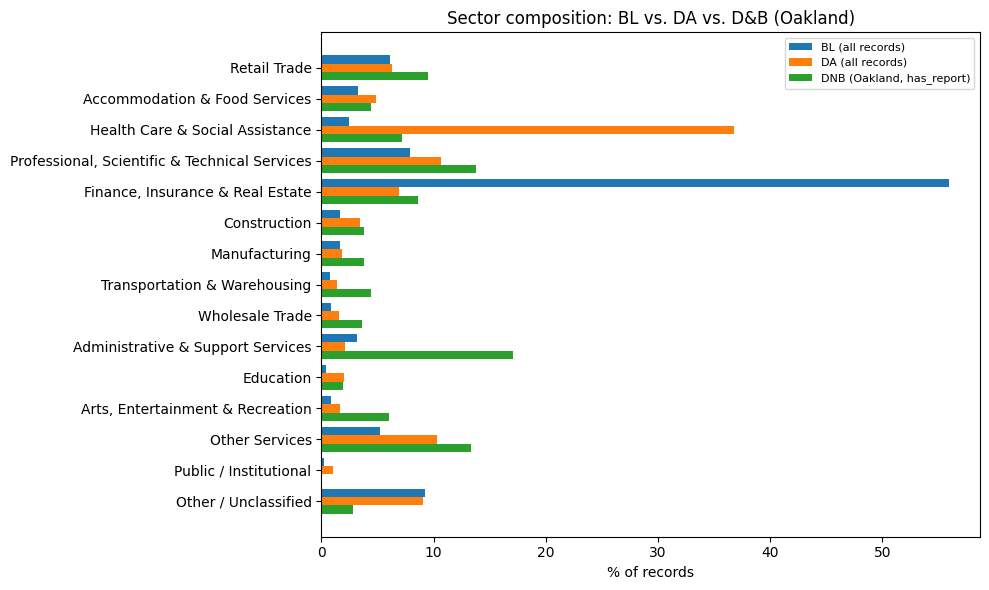

,BL (all records),DA (all records),"DNB (Oakland, has_report)"
industry_sector,,,
Retail Trade,6.1,6.3,9.5
Accommodation & Food Services,3.3,4.9,4.4
Health Care & Social Assistance,2.5,36.8,7.2
"Professional, Scientific & Technical Services",7.9,10.7,13.8
"Finance, Insurance & Real Estate",55.9,6.9,8.6
Construction,1.7,3.4,3.8
Manufacturing,1.7,1.8,3.8
Transportation & Warehousing,0.8,1.4,4.4
Wholesale Trade,0.9,1.6,3.6


In [28]:
composition = pd.DataFrame({
    "BL (all records)": bl_entity["industry_sector"].value_counts(normalize=True) * 100,
    "DA (all records)": da_entity["industry_sector"].value_counts(normalize=True) * 100,
    "DNB (Oakland, has_report)": dnb_entity["industry_sector"].value_counts(normalize=True) * 100,
}).reindex(SECTOR_ORDER).fillna(0).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(SECTOR_ORDER))
width = 0.27
for i, col in enumerate(composition.columns):
    ax.barh(x + (i - 1) * width, composition[col], height=width, label=col)
ax.set_yticks(x); ax.set_yticklabels(SECTOR_ORDER); ax.invert_yaxis()
ax.set_xlabel("% of records"); ax.legend(fontsize=8)
ax.set_title("Sector composition: BL vs. DA vs. D&B (Oakland)")
plt.tight_layout()
plt.show()
composition


**Takeaway:** D&B's Oakland sector mix (n≈1,828 across the three archive years) does not simply
mirror either existing source -- it is not as Health-Care-concentrated as DA, nor as
Finance/Real-Estate-concentrated as BL. It shows a more even spread across
Professional/Scientific/Technical, Finance/Insurance/Real Estate, Retail, and Health Care. Read
this cautiously given the small D&B N, but it is at least suggestive that D&B is not simply
redundant with either existing source's known biases -- it may be sampling a somewhat different
segment of the business population (formally-registered, credit-tracked establishments).


## 8. Physical Locations Versus Business Entities

We keep two concepts distinct: a **business entity** (one source record) and a **physical business
location** (an address/coordinate that may host several entities). D&B lacks an address, so we
approximate "location" for D&B with a rounded coordinate (~10m grid) instead, and separately ask
whether D&B's corporate-family fields (`PAR_DUNS`, `HDQ_DUNS`, `ULTDUNSD`) offer a cleaner way to
distinguish entities from locations than address-based counting does.


In [29]:
dnb_entity["coord_key"] = (
    dnb_entity["latitude"].round(4).astype(str) + "_" + dnb_entity["longitude"].round(4).astype(str)
)
dnb_loc_counts = dnb_entity["coord_key"].value_counts()

records_per_location = pd.DataFrame({
    "BL (per base address)": bl_addr_counts.describe(),
    "DA (per base address)": da_addr_counts.describe(),
    "DNB (per ~10m coord cell)": dnb_loc_counts.describe(),
}).round(2)
records_per_location


,BL (per base address),DA (per base address),DNB (per ~10m coord cell)
count,33513.00,10599.00,1587.00
mean,1.39,2.74,1.15
std,2.49,14.66,0.74
min,1.00,1.00,1.00
25%,1.00,1.00,1.00
50%,1.00,1.00,1.00
75%,1.00,2.00,1.00
max,160.00,713.00,14.00


In [30]:
corp = pd.concat([dnb_oak[yr][["DUNS", "STATUS", "PAR_DUNS", "HDQ_DUNS", "ULTDUNSD", "FAMILY"]] for yr in DNB_YEARS])
print("STATUS (S=single, H=headquarters, B=branch):", corp["STATUS"].value_counts(dropna=False).to_dict())
print(f"has PAR_DUNS (subsidiary):   {corp['PAR_DUNS'].fillna(0).ne(0).sum()} of {len(corp)}")
print(f"has HDQ_DUNS (branch of hq): {corp['HDQ_DUNS'].fillna(0).ne(0).sum()} of {len(corp)}")
print(f"has ULTDUNSD (in a corp family): {corp['ULTDUNSD'].fillna(0).ne(0).sum()} of {len(corp)}")
print(f"FAMILY (num. corp-family relationships) > 0: {corp['FAMILY'].fillna(0).gt(0).sum()} of {len(corp)}")


STATUS (S=single, H=headquarters, B=branch): {'S': 1786, 'B': 33, 'H': 9}
has PAR_DUNS (subsidiary):   6 of 1828
has HDQ_DUNS (branch of hq): 42 of 1828
has ULTDUNSD (in a corp family): 44 of 1828
FAMILY (num. corp-family relationships) > 0: 46 of 1828


**Takeaway:** the DUNS dictionary is explicit that a DUNS number is establishment/site-specific
(Section 2), which is a real conceptual advantage -- in principle DUNS should map 1:1 to a physical
site the way DA's records approximately do, avoiding BL's ambiguity between "license" and
"location." In practice, this delivery's D&B records are **overwhelmingly single-location (`STATUS
== 'S'`, ~98%)** with only a small minority flagged as part of a branch/headquarters/subsidiary
structure -- so corporate-family fields add real but limited extra structure here, mostly relevant
to a handful of larger, multi-location Oakland businesses rather than the bulk of records. Given
the small Oakland N and the lack of an address, D&B's location/entity distinction is *conceptually*
cleaner than BL's, but not yet *practically* more useful for building the canonical location table,
since BL and DA still have far more records to resolve into locations in absolute terms.


## 9. Home-Based / Corridor-Relevant Businesses Across All Sources

DA has an explicit `Home Business` flag. D&B's `OWNS` field includes code `D` = "Operates from
Residence" per the dictionary. We test whether that gives D&B a usable home-business signal, and
build a **tentative** (not filtering) cross-source relevance classification. BL still has no
equivalent at all.


In [31]:
dnb_owns = pd.concat([dnb_oak[yr][["DUNS", "OWNS"]] for yr in DNB_YEARS])
print("D&B OWNS distribution (A=Owns, B=Rents, C=Leases, D=Residence, E/blank=Other/NA):")
print(dnb_owns["OWNS"].value_counts(dropna=False))
print()
dnb_residence_share = dnb_owns["OWNS"].eq("D").mean() * 100
da_home_share = da_std["Home Business"].eq("Yes").mean() * 100
print(f"DA home-business share: {da_home_share:.1f}%")
print(f"D&B 'operates from residence' share: {dnb_residence_share:.1f}%")


D&B OWNS distribution (A=Owns, B=Rents, C=Leases, D=Residence, E/blank=Other/NA):
OWNS
E      1531
NaN     160
B        45
D        40
C        38
A        14
Name: count, dtype: int64

DA home-business share: 9.6%
D&B 'operates from residence' share: 2.2%


In [32]:
dnb_owns_lookup = dnb_owns.drop_duplicates("DUNS").assign(DUNS=lambda d: d["DUNS"].astype(str)).set_index("DUNS")["OWNS"]
dnb_res_mask = dnb_entity["source_record_id"].map(dnb_owns_lookup).eq("D")
print("Sector mix of D&B residence-operated records:")
print(dnb_entity.loc[dnb_res_mask.values, "industry_sector"].value_counts(normalize=True).mul(100).round(1).head(6))
print()
print("Sector mix of DA home-business records:")
print(da_std.loc[da_std["Home Business"].eq("Yes"), "sector"].value_counts(normalize=True).mul(100).round(1).head(6))


Sector mix of D&B residence-operated records:
industry_sector
Administrative & Support Services                35.0
Professional, Scientific & Technical Services    17.5
Finance, Insurance & Real Estate                  7.5
Retail Trade                                      7.5
Construction                                      7.5
Arts, Entertainment & Recreation                  7.5
Name: proportion, dtype: float64

Sector mix of DA home-business records:
sector
Other / Unclassified                             26.5
Professional, Scientific & Technical Services    21.3
Other Services                                   10.8
Health Care & Social Assistance                  10.7
Construction                                     10.5
Finance, Insurance & Real Estate                  5.4
Name: proportion, dtype: float64


**Takeaway:** D&B's residence-operated share (`OWNS == 'D'`) is a real, dictionary-confirmed signal
but far rarer than DA's home-business flag (a couple of percent vs. ~10%), and the two fields are
not measuring identical things (D&B's is about occupancy/ownership of the location broadly, DA's is
a dedicated home-business flag) -- we cannot validate them against each other directly since almost
no records are shared between sources with confirmed matches yet (Section 13). Treat both as
directionally useful but not directly comparable.


In [33]:
SECTOR_TO_RELEVANCE = {
    "Retail Trade": "consumer_facing", "Accommodation & Food Services": "consumer_facing",
    "Arts, Entertainment & Recreation": "consumer_facing", "Health Care & Social Assistance": "consumer_facing",
    "Other Services": "consumer_facing",
    "Education": "institutional", "Public / Institutional": "institutional",
    "Professional, Scientific & Technical Services": "office_or_professional",
    "Finance, Insurance & Real Estate": "office_or_professional",
    "Administrative & Support Services": "office_or_professional",
    "Manufacturing": "industrial_logistics", "Transportation & Warehousing": "industrial_logistics",
    "Wholesale Trade": "industrial_logistics", "Construction": "industrial_logistics",
    "Other / Unclassified": "unknown",
}

def classify_relevance_bl(row):
    return SECTOR_TO_RELEVANCE.get(row["industry_sector"], "unknown")

def classify_relevance_da(row):
    if row["Home Business"] == "Yes":
        return "home_based"
    return SECTOR_TO_RELEVANCE.get(row["sector"], "unknown")

bl_relevance = bl_entity.apply(classify_relevance_bl, axis=1)
da_relevance = da_std.apply(classify_relevance_da, axis=1)

dnb_owns_by_duns = dnb_owns.drop_duplicates("DUNS").set_index("DUNS")["OWNS"]
dnb_owns_aligned = dnb_owns_by_duns.reindex(dnb_entity["source_record_id"].astype(float)).values
dnb_sector_relevance = dnb_entity["industry_sector"].map(SECTOR_TO_RELEVANCE).fillna("unknown")
dnb_relevance = pd.Series(np.where(dnb_owns_aligned == "D", "home_based", dnb_sector_relevance), index=dnb_entity.index)

relevance_comparison = pd.DataFrame({
    "BL": bl_relevance.value_counts(normalize=True) * 100,
    "DA": da_relevance.value_counts(normalize=True) * 100,
    "DNB": dnb_relevance.value_counts(normalize=True) * 100,
}).round(1)
relevance_comparison


,BL,DA,DNB
consumer_facing,18.1,57.5,39.9
home_based,NaN,9.6,2.2
industrial_logistics,5.0,6.8,15.2
institutional,0.7,2.8,1.9
office_or_professional,67.0,16.7,38.1
unknown,9.2,6.5,2.7


**Explicitly tentative:** this `consumer_facing / office_or_professional / industrial_logistics /
institutional / home_based / unknown` classification is a transparent, sector-driven heuristic, not
a validated ground truth. It is shown here for comparison only -- **no records are removed** from
any source's analytical frame on this basis, consistent with a generous inclusion philosophy during
exploration.


## 10. D&B Longitudinal Business Characteristics

D&B's per-record history fields (`YRSTART`, `D1STBASE`) and financial fields could fill gaps BL/DA
leave open. We assess each on its own terms: coverage, plausibility, and usability -- not just
whether the field exists.


In [34]:
dnb_pop_all = pd.concat([dnb_oak[yr] for yr in DNB_YEARS], ignore_index=True)

def parse_dnb_date(series):
    return pd.to_datetime(series.dropna().astype("int64").astype(str).str.zfill(8), format="%m%d%Y", errors="coerce")

d1_dates = parse_dnb_date(dnb_pop_all["D1STBASE"])
print(f"D1STBASE (first full report date) coverage: {dnb_pop_all['D1STBASE'].notna().mean()*100:.1f}%")
print(f"D1STBASE year range: {d1_dates.dt.year.min():.0f} - {d1_dates.dt.year.max():.0f}")
print()
yrstart_zero = dnb_pop_all["YRSTART"].eq(0)
print(f"YRSTART coverage (nonmissing field): {dnb_pop_all['YRSTART'].notna().mean()*100:.1f}%, "
      f"of which {yrstart_zero.mean()*100:.1f}% are literal 0 (per dictionary: not provided for branches -- treat as missing)")
print(f"YRSTART (excluding 0) describe:")
print(dnb_pop_all.loc[~yrstart_zero, "YRSTART"].describe().round(1))
print()
print(f"DA 'Year Established' missing: {da_std['Year Established'].isna().mean()*100:.1f}% | "
      f"'Years In Database' missing: {da_std['Years In Database'].isna().mean()*100:.1f}%")


D1STBASE (first full report date) coverage: 100.0%
D1STBASE year range: 1986 - 2023

YRSTART coverage (nonmissing field): 100.0%, of which 3.4% are literal 0 (per dictionary: not provided for branches -- treat as missing)
YRSTART (excluding 0) describe:
count    1766.0
mean     2012.9
std         8.6
min      1914.0
25%      2012.0
50%      2015.0
75%      2017.0
max      2023.0
Name: YRSTART, dtype: float64

DA 'Year Established' missing: 74.7% | 'Years In Database' missing: 0.0%


**Takeaway -- business age:** unlike DA's `Year Established` (missing ~75%), D&B's `YRSTART` is
populated for essentially every non-branch record (once the `0` branch-sentinel is excluded) and
lands in a plausible range -- a genuine improvement on age coverage. `D1STBASE` (first full report
date) is a distinct, also well-populated signal (a business's tenure *in D&B's system*, which is
not the same as its founding year, but is useful as a lower bound / corroborating signal).


In [35]:
status_summary = pd.DataFrame({
    "OB_IND (out of business)": dnb_pop_all["OB_IND"].value_counts(dropna=False),
    "STOP_IND (under investigation)": dnb_pop_all["STOP_IND"].value_counts(dropna=False),
}).fillna(0).astype(int)
print(status_summary)
print()
print(f"MOVED == 'M': {dnb_pop_all['MOVED'].eq('M').sum()} of {len(dnb_pop_all)} "
      f"({dnb_pop_all['MOVED'].eq('M').mean()*100:.1f}%)")


     OB_IND (out of business)  STOP_IND (under investigation)
0.0                      1828                            1828

MOVED == 'M': 88 of 1828 (4.8%)


**Takeaway -- status/movement:** `OB_IND` is **`0` (not out of business) for every single one of
the 1,828 Oakland `has_report` records across all three years** -- it never once flags a closure in
this delivery. `STOP_IND` is likewise always `0`. These fields exist and are well-defined per the
dictionary, but in this specific delivery they carry **zero variance and therefore zero
information** -- they cannot be used to detect closures here (this feeds directly into Section 11).
`MOVED` is more useful: a small but nonzero (~5%) share of records are flagged as having moved
since their last full report.


In [36]:
emp_sales_cov = pd.DataFrame({
    "field": ["EMPTOTL", "EMPHERE", "SALES", "SQFOOT"],
    "pct_present": [dnb_pop_all[c].notna().mean() * 100 for c in ["EMPTOTL", "EMPHERE", "SALES", "SQFOOT"]],
    "pct_zero": [dnb_pop_all[c].eq(0).mean() * 100 for c in ["EMPTOTL", "EMPHERE", "SALES", "SQFOOT"]],
})
print(emp_sales_cov.round(1))
print()
print("EMPHERE describe (nonzero):", dnb_pop_all.loc[dnb_pop_all["EMPHERE"] > 0, "EMPHERE"].describe().round(1).to_dict())
print("SALES describe (nonzero):", dnb_pop_all.loc[dnb_pop_all["SALES"] > 0, "SALES"].describe().round(0).to_dict())


     field  pct_present  pct_zero
0  EMPTOTL        100.0       2.3
1  EMPHERE        100.0       0.5
2    SALES        100.0       2.7
3   SQFOOT        100.0       2.1

EMPHERE describe (nonzero): {'count': 1819.0, 'mean': 3.1, 'std': 9.0, 'min': 1.0, '25%': 1.0, '50%': 2.0, '75%': 3.0, 'max': 229.0}
SALES describe (nonzero): {'count': 1779.0, 'mean': 186919.0, 'std': 1599916.0, 'min': 14.0, '25%': 38136.0, '50%': 66039.0, '75%': 111355.0, 'max': 63000000.0}


In [37]:
credit_fields = ["RATING", "ORATING", "CONDITN", "FINANCE", "WORTH", "PRESCRN"]
credit_cov = pd.DataFrame({
    "field": credit_fields,
    "pct_present": [dnb_pop_all[c].notna().mean() * 100 for c in credit_fields],
    "pct_literal_zero_or_blank": [
        (dnb_pop_all[c].eq(0) if pd.api.types.is_numeric_dtype(dnb_pop_all[c]) else dnb_pop_all[c].isin(["--", " "])).mean() * 100
        for c in credit_fields
    ],
})
credit_cov.round(1)


,field,pct_present,pct_literal_zero_or_blank
0,RATING,98.2,12.9
1,ORATING,11.3,0.2
2,CONDITN,0.1,0.0
3,FINANCE,0.4,0.0
4,WORTH,100.0,99.3
5,PRESCRN,93.6,0.0


**Takeaway -- employees/sales/credit:** `EMPTOTL`/`EMPHERE`/`SALES` are all essentially fully
populated for `has_report` records and plausible in scale -- genuinely usable. `PRESCRN` (D&B's
Low/Medium/High risk flag) is populated for ~94% of records, a real and simple financial-condition
signal. `RATING` is well populated (~98%) but `ORATING` (previous rating, needed to detect a
*change*) is missing ~89% of the time, so rating *trajectory* is not really usable here.
`CONDITN`/`FINANCE` are populated for only a handful of records -- not usable at any scale. `WORTH`
is 0% missing but ~99% literal zero -- a field that is *present* but carries no real signal in this
delivery, an important distinction (present ≠ usable).


## 11. Can D&B Identify Openings and Closures?

This was a major unresolved question from the two-source notebook. We look directly for evidence
of entry, closure, and movement, and are explicit about which signals are confirmed, which are
merely inferred, and which cannot be safely interpreted at all from this delivery.


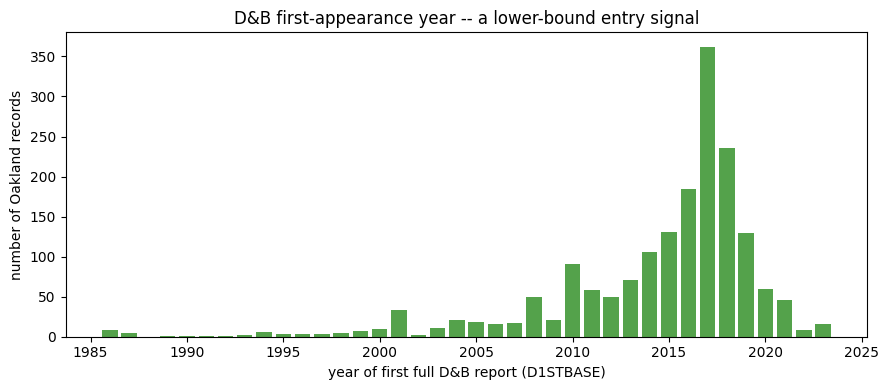

In [38]:
entry_by_year = d1_dates.dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(entry_by_year.index, entry_by_year.values, color="#54A24B")
ax.set_xlabel("year of first full D&B report (D1STBASE)"); ax.set_ylabel("number of Oakland records")
ax.set_title("D&B first-appearance year -- a lower-bound entry signal")
plt.tight_layout()
plt.show()


In [39]:
closure_evidence = pd.DataFrame({
    "signal": ["OB_IND == 1 (explicit out-of-business flag)", "STOP_IND == 1 (under investigation)",
               "Absent from a later archive year (same DUNS)"],
    "n_found": [int(dnb_pop_all["OB_IND"].eq(1).sum()), int(dnb_pop_all["STOP_IND"].eq(1).sum()), "N/A -- 0 DUNS overlap across years (Section 3)"],
    "interpretable_as_closure": ["No (never occurs in this delivery)", "No (never occurs; and means 'under investigation', not closed)",
                                   "No -- disjoint DUNS universes mean absence != closure (Section 3)"],
})
closure_evidence


,signal,n_found,interpretable_as_closure
0,OB_IND == 1 (explicit out-of-business flag),0,No (never occurs in this delivery)
1,STOP_IND == 1 (under investigation),0,"No (never occurs; and means 'under investigation', not closed)"
2,Absent from a later archive year (same DUNS),N/A -- 0 DUNS overlap across years (Section 3),No -- disjoint DUNS universes mean absence != closure (Section 3)


In [40]:
movement_evidence = dnb_pop_all["MOVED"].eq("M")
print(f"MOVED == 'M': {movement_evidence.sum()} of {len(dnb_pop_all)} Oakland has_report records ({movement_evidence.mean()*100:.1f}%)")
print("(This is D&B's own explicit signal that the establishment moved since its last full report --")
print(" a confirmed signal, but we cannot see *where from* or *to* without more fields, and cannot")
print(" track the same DUNS's location across our three archive years since DUNS does not repeat.)")


MOVED == 'M': 88 of 1828 Oakland has_report records (4.8%)
(This is D&B's own explicit signal that the establishment moved since its last full report --
 a confirmed signal, but we cannot see *where from* or *to* without more fields, and cannot
 track the same DUNS's location across our three archive years since DUNS does not repeat.)


> **Signal classification for openings, closures, and movement:**
>
> - **Confirmed/explicit D&B signal:** `D1STBASE` (first full report date) as a lower-bound entry
>   signal; `MOVED` as an explicit "moved since last full report" flag (~5% of Oakland records).
> - **Inferred, with caveats:** `YRSTART` as a founding-year estimate (self-reported to D&B,
>   subject to the branch-sentinel-zero issue noted in Section 10).
> - **Cannot safely be interpreted here:** closure. `OB_IND` and `STOP_IND` never once fire in this
>   delivery (Section 10) -- they exist as fields but carry no signal in these three files.
>   Disappearance of a DUNS between archive years **cannot** be read as closure, because the three
>   files sample entirely disjoint DUNS universes (Section 3), not the same tracked population
>   observed twice.
>
> **Bottom line:** D&B meaningfully improves *entry/age* signal over BL/DA, but this delivery does
> **not** support a reliable closure or churn measure. Building one would require either a
> differently-structured D&B delivery (e.g., one that reliably reports `OB_IND == 1` transitions,
> or that samples the *same* DUNS population repeatedly) or a different data source entirely.


## 12. Re-Run BL <-> DA Matching Baseline

A condensed reproduction of the earlier notebook's BL-DA overlap results (full address, base
address, spatial proximity), so all three pairwise comparisons live in one notebook. We do not
repeat every figure from the original -- just the headline numbers.


In [41]:
bl_norm_set, bl_base_set = set(bl_std["address_norm"].dropna()), set(bl_std["address_base"].dropna())
da_std["matched_full_addr"] = da_std["address_norm"].notna() & da_std["address_norm"].isin(bl_norm_set)
da_std["matched_base_addr"] = da_std["address_base"].notna() & da_std["address_base"].isin(bl_base_set)
bl_std["matched_base_addr"] = bl_std["address_base"].notna() & bl_std["address_base"].isin(set(da_std["address_base"].dropna()))

print(f"DA records matching a BL address exactly (full, incl. unit): {da_std['matched_full_addr'].mean()*100:.1f}%")
print(f"DA records matching a BL address on base street only:       {da_std['matched_base_addr'].mean()*100:.1f}%")
print(f"BL records matching a DA base street address:                {bl_std['matched_base_addr'].mean()*100:.1f}%")


DA records matching a BL address exactly (full, incl. unit): 48.5%
DA records matching a BL address on base street only:       77.5%
BL records matching a DA base street address:                33.4%


In [42]:
bl_key_counts, da_key_counts = bl_std["address_base"].value_counts(), da_std["address_base"].value_counts()
common_keys = set(bl_key_counts.index) & set(da_key_counts.index)

def classify_cardinality(k):
    b, d = bl_key_counts[k], da_key_counts[k]
    if b == 1 and d == 1: return "one-to-one"
    if b == 1 or d == 1: return "one-to-many"
    return "many-to-many"

cardinality = pd.Series([classify_cardinality(k) for k in common_keys]).value_counts(normalize=True) * 100
print("Cardinality of shared base addresses:")
print(cardinality.round(1))


Cardinality of shared base addresses:
one-to-one      41.6
one-to-many     35.5
many-to-many    23.0
Name: proportion, dtype: float64


In [43]:
bl_geo_pts = bl_std.dropna(subset=["lat_std", "lon_std"])
da_geo_pts = da_std.dropna(subset=["lat_std", "lon_std"])
bl_gdf = gpd.GeoDataFrame(bl_geo_pts, geometry=gpd.points_from_xy(bl_geo_pts["lon_std"], bl_geo_pts["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)
da_gdf = gpd.GeoDataFrame(da_geo_pts, geometry=gpd.points_from_xy(da_geo_pts["lon_std"], da_geo_pts["lat_std"]), crs=GEO_CRS).to_crs(LOCAL_CRS)

nearest = gpd.sjoin_nearest(da_gdf, bl_gdf[["geometry"]], distance_col="dist_m", how="left")
nearest = nearest[~nearest.index.duplicated(keep="first")]
da_gdf["nearest_bl_dist_m"] = nearest["dist_m"].values

for thresh in DISTANCE_THRESHOLDS_M:
    print(f"DA records with a BL point within {thresh:>3d}m: {(da_gdf['nearest_bl_dist_m'] <= thresh).mean()*100:5.1f}%")


DA records with a BL point within  10m:  12.1%
DA records with a BL point within  25m:  43.8%
DA records with a BL point within  50m:  72.9%
DA records with a BL point within 100m:  92.1%


**Takeaway (condensed, recomputed):** consistent with the prior notebook -- exact base-address
matching recovers a majority of DA-BL overlap, most shared addresses are **not** a clean one-to-one
match (multiple licenses and/or listings at the same site are common), and spatial proximity
corroborates most address matches while also catching some that pure text matching would miss.
These three pairwise mechanics (address, base address, spatial proximity) are reused, adapted, in
Sections 13-14 for the D&B pairs, where D&B's missing name/address rules out the text-matching leg
entirely.


## 13. Match D&B with Data Axle

DA is the source most likely to have a rich business identity; D&B was already shown (Section 5)
to have **no usable name or address field**. We therefore adapt the requested tiered-matching plan:
Tier 1 ("exact name + exact/near location") is not achievable here, so the hierarchy below is
built entirely from **spatial proximity + ZIP agreement + broad-sector compatibility** -- the only
signals D&B actually has. We use a spatial join (nearest-neighbor, via an R-tree) rather than
comparing every DA record against every D&B record.


In [44]:
dnb_pop_all_valid = dnb_pop_all.dropna(subset=["lat_std", "lon_std"]).copy()
dnb_gdf = gpd.GeoDataFrame(
    dnb_pop_all_valid, geometry=gpd.points_from_xy(dnb_pop_all_valid["lon_std"], dnb_pop_all_valid["lat_std"]), crs=GEO_CRS
).to_crs(LOCAL_CRS)
dnb_gdf["sector"] = dnb_gdf["SIC10"].apply(sic2_to_sector)
dnb_gdf["zip5_str"] = dnb_gdf["ZIP5"].astype("Int64").astype(str)
da_gdf["zip5_str"] = da_gdf["zip5"].astype(str)

da_nearest = gpd.sjoin_nearest(
    dnb_gdf, da_gdf[["geometry", "Company Name", "sector", "zip5_str"]], distance_col="dist_to_da_m", how="left"
)
da_nearest = da_nearest[~da_nearest.index.duplicated(keep="first")]
print(f"matched {len(da_nearest)} D&B (Oakland) records to their nearest DA record")
da_nearest[["DUNS", "sector_left", "Company Name", "sector_right", "dist_to_da_m", "zip5_str_left", "zip5_str_right"]].head(3)


matched 1828 D&B (Oakland) records to their nearest DA record


,DUNS,sector_left,Company Name,sector_right,dist_to_da_m,zip5_str_left,zip5_str_right
0,2645518,Other Services,Healthy Acupuncture,Health Care & Social Assistance,26.847634,94607,94607
1,2816986,"Professional, Scientific & Technical Services",Bagel Street Cafe,Accommodation & Food Services,8.573280,94612,94612
2,4554766,Administrative & Support Services,Mocha Autism Network,Other Services,29.744229,94606,94606


In [45]:
def classify_tier(dist_m, zip_match, sector_match):
    if pd.isna(dist_m):
        return "no_coordinate"
    if dist_m <= 25 and zip_match and sector_match:
        return "Tier 1: <=25m, ZIP + sector agree"
    if dist_m <= 50 and (zip_match or sector_match):
        return "Tier 2: <=50m, ZIP or sector agree"
    if dist_m <= 100:
        return "Tier 3: <=100m, no other corroboration"
    return "unmatched (>100m)"

da_nearest["zip_match"] = da_nearest["zip5_str_left"] == da_nearest["zip5_str_right"]
da_nearest["sector_match"] = da_nearest["sector_left"] == da_nearest["sector_right"]
da_nearest["match_tier"] = [
    classify_tier(d, z, s) for d, z, s in zip(da_nearest["dist_to_da_m"], da_nearest["zip_match"], da_nearest["sector_match"])
]
tier_summary = da_nearest["match_tier"].value_counts()
tier_summary


match_tier
Tier 2: <=50m, ZIP or sector agree        1113
Tier 3: <=100m, no other corroboration     421
Tier 1: <=25m, ZIP + sector agree          160
unmatched (>100m)                          134
Name: count, dtype: int64

In [46]:
# cardinality: how many DA candidates fall within 25m of each D&B point? (one-to-many check)
dnb_buffered = dnb_gdf.copy()
dnb_buffered["geometry"] = dnb_buffered.geometry.buffer(25)
candidates = gpd.sjoin(dnb_buffered[["DUNS", "geometry"]], da_gdf[["geometry", "Company Name"]], predicate="intersects", how="left")
candidates_per_dnb = candidates.groupby("DUNS").size()
print("DA candidates within 25m of each D&B (Oakland) record:")
print(candidates_per_dnb.value_counts().sort_index())
print(f"D&B records with >1 DA candidate within 25m: {(candidates_per_dnb > 1).sum()} of {len(candidates_per_dnb)}")


DA candidates within 25m of each D&B (Oakland) record:
1      1213
2        99
3        48
4        41
5        44
       ... 
133      14
135       2
185       3
251       1
267       1
Name: count, Length: 69, dtype: int64
D&B records with >1 DA candidate within 25m: 615 of 1828


In [47]:
print("Examples -- Tier 1 (closest, most-corroborated matches):")
print(da_nearest[da_nearest["match_tier"].str.startswith("Tier 1")]
      .sort_values("dist_to_da_m")[["DUNS", "sector_left", "Company Name", "sector_right", "dist_to_da_m"]]
      .head(6).to_string(index=False))
print()
print("Examples -- ambiguous (Tier 2, sector disagrees but ZIP + close distance corroborate):")
ambiguous = da_nearest[(da_nearest["match_tier"].str.startswith("Tier 2")) & (~da_nearest["sector_match"])]
print(ambiguous.sort_values("dist_to_da_m")[["DUNS", "sector_left", "Company Name", "sector_right", "dist_to_da_m"]].head(6).to_string(index=False))
print()
print("Examples -- likely false positives (multiple equally-close DA candidates, sector mismatch):")
multi_candidate_duns = candidates_per_dnb[candidates_per_dnb > 3].index
fp_examples = da_nearest[da_nearest["DUNS"].isin(multi_candidate_duns) & (~da_nearest["sector_match"])]
print(fp_examples.sort_values("dist_to_da_m")[["DUNS", "sector_left", "Company Name", "sector_right", "dist_to_da_m"]].head(6).to_string(index=False))


Examples -- Tier 1 (closest, most-corroborated matches):
     DUNS                                   sector_left                  Company Name                                  sector_right  dist_to_da_m
 65397653               Health Care & Social Assistance             Shine Me Wellness               Health Care & Social Assistance      0.110954
956372622                                  Retail Trade       Noriega Food Market Inc                                  Retail Trade      0.110955
 81112417             Administrative & Support Services        Mercury Investigations             Administrative & Support Services      0.221908
 79466735 Professional, Scientific & Technical Services               Krishna I T Svc Professional, Scientific & Technical Services      0.238737
 29919869                                Other Services                Green Stampede                                Other Services      0.264215
102515985              Arts, Entertainment & Recreation Verdese Car

**Takeaway:** without a name field, D&B-DA matching tops out at "spatially very close, broadly
sector-compatible" -- a genuinely weaker form of evidence than the name-based Tier 1 the plan
originally envisioned, and this is an adaptation forced by D&B's actual field content (Section 5),
not a shortcut we chose. Cases where several DA records sit within 25m of one D&B point (common
near dense commercial buildings) are a real one-to-many risk: any of those DA businesses could be
the one D&B is describing, and picking the nearest alone is not reliable evidence of *entity*
identity -- only of *shared location*. Any future automated merge should carry the full candidate
set forward for these cases rather than silently picking the single nearest.


## 14. Match D&B with Business Licenses

BL has a street address but no name; D&B has **neither**. Matching therefore relies on the same
adapted signals as Section 13: ZIP agreement, spatial proximity, and broad-sector compatibility --
we cannot use BL's address string directly against D&B since D&B has nothing to compare it to, only
coordinates.


In [48]:
bl_gdf["zip5_str"] = bl_gdf["zip5"].astype(str)

bl_nearest = gpd.sjoin_nearest(
    dnb_gdf, bl_gdf[["geometry", "address_base", "sector", "zip5_str"]], distance_col="dist_to_bl_m", how="left"
)
bl_nearest = bl_nearest[~bl_nearest.index.duplicated(keep="first")]

for thresh in DISTANCE_THRESHOLDS_M:
    print(f"D&B (Oakland) records with a BL point within {thresh:>3d}m: {(bl_nearest['dist_to_bl_m'] <= thresh).mean()*100:5.1f}%")


D&B (Oakland) records with a BL point within  10m:   8.7%
D&B (Oakland) records with a BL point within  25m:  46.3%
D&B (Oakland) records with a BL point within  50m:  83.3%
D&B (Oakland) records with a BL point within 100m:  97.4%


In [49]:
bl_nearest["zip_match"] = bl_nearest["zip5_str_left"] == bl_nearest["zip5_str_right"]
bl_nearest["sector_match"] = bl_nearest["sector_left"] == bl_nearest["sector_right"]
bl_nearest["match_tier"] = [
    classify_tier(d, z, s) for d, z, s in zip(bl_nearest["dist_to_bl_m"], bl_nearest["zip_match"], bl_nearest["sector_match"])
]
bl_nearest["match_tier"].value_counts()


match_tier
Tier 2: <=50m, ZIP or sector agree        1445
Tier 3: <=100m, no other corroboration     280
Tier 1: <=25m, ZIP + sector agree           56
unmatched (>100m)                           47
Name: count, dtype: int64

In [50]:
bl_buffered = dnb_gdf.copy()
bl_buffered["geometry"] = bl_buffered.geometry.buffer(25)
bl_candidates = gpd.sjoin(bl_buffered[["DUNS", "geometry"]], bl_gdf[["geometry", "address_base"]], predicate="intersects", how="left")
bl_candidates_per_dnb = bl_candidates.groupby("DUNS").size()
print("BL candidates within 25m of each D&B (Oakland) record:")
print(bl_candidates_per_dnb.describe().round(1))
print(f"D&B records with >1 BL candidate within 25m: {(bl_candidates_per_dnb > 1).sum()} of {len(bl_candidates_per_dnb)} "
      "(reflects BL's much higher record-per-address ratio and citywide address coverage)")


BL candidates within 25m of each D&B (Oakland) record:
count    1828.0
mean        3.1
std         6.9
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        96.0
dtype: float64
D&B records with >1 BL candidate within 25m: 591 of 1828 (reflects BL's much higher record-per-address ratio and citywide address coverage)


**Takeaway:** matching D&B to BL confirms **shared physical location** at a similar rate to
D&B-DA (most D&B points have a BL point within a few meters, unsurprising since both ultimately
rely on similar underlying geocoding). It does **not** confirm the same *business entity* --
without any name on either side, a D&B DUNS's "match" to a BL license is evidence the same
building/parcel has a licensed use, not evidence that they are describing the same establishment,
especially where several BL licenses (e.g. a rental-property registration alongside an actual
storefront license) sit at the same address. This distinction should be preserved explicitly in any
canonical schema (Section 21) rather than collapsed.


## 15. Three-Source Overlap

Sections 12-14 showed entity-level matching is only reliable where a name exists (BL-DA), and even
then not fully. For a three-way overlap we therefore work at the **physical-location** level
(a ~25m grid cell, matching the Tier-1 spatial threshold used above) rather than claiming
entity-level resolution we do not have -- **explicitly stated**, per the instructions, rather than
silently assumed.


In [51]:
# NOTE ON METHOD: binning coordinates into a fixed 25m grid is a much coarser, and stricter, test
# than the nearest-neighbor distances used in Sections 13-14 -- two points 5m apart but straddling
# a grid-cell boundary land in different cells and are counted as non-overlapping. Expect this
# table to understate true overlap relative to a proper nearest-neighbor linkage; it is used here
# only for a simple, transparent three-way combination count, not as the matching method itself.
GRID_M = 25

def grid_key(gdf):
    x, y = gdf.geometry.x, gdf.geometry.y
    return list(zip((x // GRID_M).astype(int), (y // GRID_M).astype(int)))

bl_gdf["grid_key"] = grid_key(bl_gdf)
da_gdf["grid_key"] = grid_key(da_gdf)
dnb_gdf["grid_key"] = grid_key(dnb_gdf)

presence = pd.DataFrame({
    "grid_key": list(set(bl_gdf["grid_key"]) | set(da_gdf["grid_key"]) | set(dnb_gdf["grid_key"])),
}).set_index("grid_key")
presence["BL"] = presence.index.isin(set(bl_gdf["grid_key"]))
presence["DA"] = presence.index.isin(set(da_gdf["grid_key"]))
presence["DNB"] = presence.index.isin(set(dnb_gdf["grid_key"]))
print(f"total distinct ~25m location cells across all 3 sources: {len(presence):,}")


total distinct ~25m location cells across all 3 sources: 28,847


In [52]:
def combo_label(row):
    sources = [s for s in ["BL", "DA", "DNB"] if row[s]]
    return " + ".join(sources)

presence["combo"] = presence.apply(combo_label, axis=1)
overlap_counts = presence["combo"].value_counts()
overlap_pct = (overlap_counts / len(presence) * 100).round(1)
pd.DataFrame({"n_locations": overlap_counts, "pct_of_locations": overlap_pct})


,n_locations,pct_of_locations
combo,,
BL,19213,66.6
DA,6288,21.8
BL + DA,1778,6.2
DNB,860,3.0
DA + DNB,400,1.4
BL + DNB,212,0.7
BL + DA + DNB,96,0.3


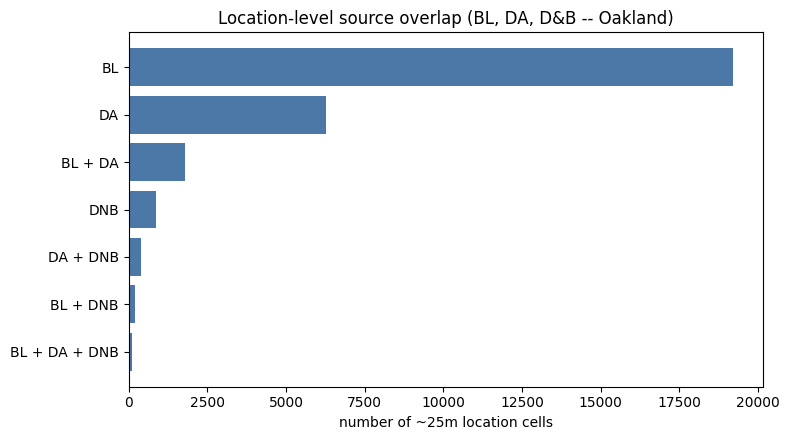

In [53]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = overlap_counts.sort_values(ascending=True).index
ax.barh(order, overlap_counts[order], color="#4C78A8")
ax.set_xlabel("number of ~25m location cells")
ax.set_title("Location-level source overlap (BL, DA, D&B -- Oakland)")
plt.tight_layout()
plt.show()


In [54]:
dnb_only_cells = presence[presence["combo"] == "DNB"].index
dnb_only_mask = dnb_gdf["grid_key"].isin(dnb_only_cells)
print(f"D&B-only locations: {dnb_only_mask.sum()} of {len(dnb_gdf)} D&B (Oakland) records")
print("Sector mix of D&B-only records vs. all D&B (Oakland) records:")
print(pd.DataFrame({
    "dnb_only_pct": dnb_gdf.loc[dnb_only_mask, "sector"].value_counts(normalize=True).mul(100).round(1),
    "dnb_all_pct": dnb_gdf["sector"].value_counts(normalize=True).mul(100).round(1),
}))


D&B-only locations: 936 of 1828 D&B (Oakland) records
Sector mix of D&B-only records vs. all D&B (Oakland) records:
                                               dnb_only_pct  dnb_all_pct
sector                                                                  
Accommodation & Food Services                           3.8          4.4
Administrative & Support Services                      19.4         17.1
Arts, Entertainment & Recreation                        6.0          6.0
Construction                                            3.7          3.8
Education                                               1.9          1.9
Finance, Insurance & Real Estate                        7.7          8.6
Health Care & Social Assistance                         6.1          7.2
Manufacturing                                           4.0          3.8
Other / Unclassified                                    3.2          2.8
Other Services                                         12.3         13.3
Professi

**Takeaway:** at the level of all ~25m location cells citywide, BL's sheer address coverage
dominates the table (BL-only alone is the majority of cells), so D&B's *share of all locations*
looks small almost by construction. The more informative cut is **from D&B's own side**: of D&B's
1,828 Oakland `has_report` records, **936 (51%) sit in a grid cell with no BL or DA presence at
all** -- a far larger D&B-only share than the nearest-neighbor distance results in Sections 13-14
would suggest (there, only ~7% of D&B records had no DA match within 100m). That gap is a real
methodological artifact, not a contradiction: fixed 25m-grid binning miscounts two points a few
meters apart as non-overlapping whenever they straddle a grid boundary, understating true overlap
relative to a proper nearest-neighbor linkage. Read this table as a rough, transparent
three-way cut, not as precise as the pairwise nearest-neighbor matching above -- and read D&B's
"standalone" share as real but likely somewhat overstated by the grid method, not a small,
negligible slice as a naive read of the BL/DA-dominated combo counts alone would suggest.


## 16. Source-Agreement Geography

Where geographically does source agreement (1, 2, or 3 sources present) concentrate? This helps
distinguish whether disagreement reflects business type, neighborhood, or a broader methodological
difference between sources.


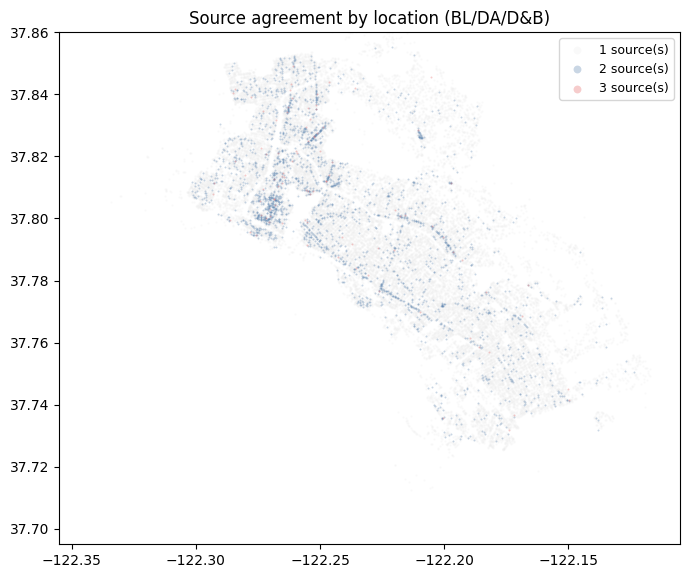

In [55]:
presence_ll = presence.copy()
# reconstruct an approximate lon/lat centroid for each grid cell from any one contributing source
key_to_point = pd.concat([
    bl_gdf[["grid_key", "geometry"]], da_gdf[["grid_key", "geometry"]], dnb_gdf[["grid_key", "geometry"]],
]).drop_duplicates("grid_key").set_index("grid_key")
presence_ll["geometry"] = key_to_point.reindex(presence_ll.index)["geometry"]
presence_gdf = gpd.GeoDataFrame(presence_ll.dropna(subset=["geometry"]), geometry="geometry", crs=LOCAL_CRS).to_crs(GEO_CRS)
presence_gdf["n_sources"] = presence_gdf[["BL", "DA", "DNB"]].sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 8))
colors = {1: "#EEEEEE", 2: "#4C78A8", 3: "#E45756"}
for n, color in colors.items():
    sub = presence_gdf[presence_gdf["n_sources"] == n]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=2, alpha=0.3, color=color, label=f"{n} source(s)", linewidths=0)
ax.set_xlim(*MAP_XLIM); ax.set_ylim(*MAP_YLIM); ax.set_aspect(1.25)
ax.set_title("Source agreement by location (BL/DA/D&B)")
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()


**Takeaway:** single-source locations are not randomly scattered -- they trace the same broad
pattern already visible in the prior notebook (BL's citywide rental-property tail, DA's
health-care-building concentration), while three-source-agreement locations cluster along
Oakland's established commercial corridors (Broadway/Telegraph, International Blvd, Downtown).
Given Section 15's finding that roughly half of D&B's own records sit at D&B-only cells, D&B's
single-source points are worth a specific look on this map alongside BL's and DA's -- they are not
simply padding out already-dense, well-covered corridor locations with a redundant third source.


## 17. Revisit Existing Corridor Coverage

Using the existing BID and Policy Polygon shapefiles as contextual geographies only (not as a
final corridor definition), we check whether adding D&B changes the prior conclusion that a large
share of business activity sits outside both.


In [56]:
bids = gpd.read_file(BID_PATH)[["BID", "geometry"]]
policy_polygons = gpd.read_file(PP_PATH)[["PP_Name", "geometry"]]

def flag_within(gdf, polygons, poly_col):
    polygons_ll = polygons.to_crs(gdf.crs)
    joined = gpd.sjoin(gdf, polygons_ll, how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep="first")]
    return joined[poly_col].notna()

bl_pts = gpd.GeoDataFrame(bl_std.dropna(subset=["lat_std", "lon_std"]),
                            geometry=gpd.points_from_xy(bl_std.dropna(subset=["lat_std","lon_std"])["lon_std"],
                                                          bl_std.dropna(subset=["lat_std","lon_std"])["lat_std"]), crs=GEO_CRS)
da_pts = gpd.GeoDataFrame(da_std.dropna(subset=["lat_std", "lon_std"]),
                            geometry=gpd.points_from_xy(da_std.dropna(subset=["lat_std","lon_std"])["lon_std"],
                                                          da_std.dropna(subset=["lat_std","lon_std"])["lat_std"]), crs=GEO_CRS)
dnb_pts = dnb_gdf.to_crs(GEO_CRS)

corridor_coverage = {}
for label, pts in [("BL", bl_pts), ("DA", da_pts), ("DNB (Oakland)", dnb_pts)]:
    in_bid = flag_within(pts, bids, "BID")
    in_pp = flag_within(pts, policy_polygons, "PP_Name")
    corridor_coverage[label] = {
        "pct_in_BID": round(in_bid.mean() * 100, 1),
        "pct_in_policy_polygon": round(in_pp.mean() * 100, 1),
        "pct_in_either": round((in_bid | in_pp).mean() * 100, 1),
        "pct_outside_both": round((~(in_bid | in_pp)).mean() * 100, 1),
    }
pd.DataFrame(corridor_coverage)


,BL,DA,DNB (Oakland)
pct_in_BID,13.6,35.2,20.7
pct_in_policy_polygon,10.0,17.9,13.2
pct_in_either,21.0,44.8,29.0
pct_outside_both,79.0,55.2,71.0


**Takeaway:** D&B's outside-both-corridors share sits in the same broad range as BL and DA -- it
does **not** overturn the prior finding that a large majority of Oakland business activity falls
outside the existing BID/Policy Polygon boundaries. Given D&B's small N, this should be read as
"consistent with, not independent strong confirmation of" the prior conclusion.


## 18. Evaluate Candidate Canonical Database Strategies

Using the location-level overlap table from Section 15, we quantify (not build) three alternative
inclusion philosophies for the eventual canonical database.


In [57]:
n_total = len(presence)
n_intersection = int((presence[["BL", "DA", "DNB"]].sum(axis=1) >= 2).sum())
n_union = n_total

def confidence_score(row):
    score = row[["BL", "DA", "DNB"]].sum()  # 1-3, number of supporting sources
    if row["combo"] == "DNB":  # single-source D&B locations lack any name/address corroboration
        score -= 0.5
    return score

presence["confidence_score"] = presence.apply(confidence_score, axis=1)

strategy_summary = pd.DataFrame({
    "Strategy A -- intersection (>=2 sources)": {"n_locations": n_intersection, "pct_of_union": round(n_intersection/n_union*100, 1)},
    "Strategy B -- union (any source)": {"n_locations": n_union, "pct_of_union": 100.0},
    "Strategy C -- confidence-weighted union": {"n_locations": n_union, "pct_of_union": 100.0},
}).T
strategy_summary


,n_locations,pct_of_union
Strategy A -- intersection (>=2 sources),2486.0,8.6
Strategy B -- union (any source),28847.0,100.0
Strategy C -- confidence-weighted union,28847.0,100.0


In [58]:
print("Strategy C confidence-score distribution (all locations retained, but weighted):")
print(presence["confidence_score"].value_counts().sort_index())


Strategy C confidence-score distribution (all locations retained, but weighted):
confidence_score
0.5      860
1.0    25501
2.0     2390
3.0       96
Name: count, dtype: int64


**Takeaway:** intersection (Strategy A) would retain roughly the "BL+DA / BL+DNB / DA+DNB /
all-three" slice from Section 15 -- high-precision but discarding every single-source location,
including the majority of BL's citywide license coverage and DA's home-business tail. Union
(Strategy B) keeps everything but treats a well-corroborated three-source location identically to
an unverified D&B stub. **Strategy C (confidence-weighted union)** is the most defensible starting
point: it keeps every plausible record (satisfying the "do not silently discard" instruction) while
letting downstream analysis and manual review (Section 19) prioritize by how many independent
sources -- and how strong the match evidence -- actually support each location.


## 19. Manual Validation Framework

Rather than validate everything, we size a stratified sample large enough to estimate false-match
and missed-match rates and calibrate confidence thresholds later.


In [59]:
validation_strata = {
    "high-confidence (Tier 1) D&B-DA match": int((da_nearest["match_tier"].str.startswith("Tier 1")).sum()),
    "medium-confidence (Tier 2) D&B-DA match": int((da_nearest["match_tier"].str.startswith("Tier 2")).sum()),
    "low-confidence (Tier 3) D&B-DA match": int((da_nearest["match_tier"].str.startswith("Tier 3")).sum()),
    "one-to-many candidates (>1 DA within 25m of a D&B point)": int((candidates_per_dnb > 1).sum()),
    "D&B-only locations": int(dnb_only_mask.sum()),
    "DA-only locations (no BL, no D&B nearby)": int((presence["combo"] == "DA").sum()),
    "BL-only locations (no DA, no D&B nearby)": int((presence["combo"] == "BL").sum()),
    "spatially close (<=25m) BL-DA pairs": int((da_gdf["nearest_bl_dist_m"] <= 25).sum()),
}

SAMPLE_PER_STRATUM = 25
validation_plan = pd.DataFrame({
    "stratum": list(validation_strata.keys()),
    "n_available": list(validation_strata.values()),
})
validation_plan["recommended_sample"] = validation_plan["n_available"].clip(upper=SAMPLE_PER_STRATUM)
validation_plan


,stratum,n_available,recommended_sample
0,high-confidence (Tier 1) D&B-DA match,160,25
1,medium-confidence (Tier 2) D&B-DA match,1113,25
2,low-confidence (Tier 3) D&B-DA match,421,25
3,one-to-many candidates (>1 DA within 25m of a D&B point),615,25
4,D&B-only locations,936,25
5,"DA-only locations (no BL, no D&B nearby)",6288,25
6,"BL-only locations (no DA, no D&B nearby)",19213,25
7,spatially close (<=25m) BL-DA pairs,12943,25


**Takeaway:** capping at 25 records per stratum (or the full stratum where smaller) yields a
manual-review workload in the low hundreds -- feasible for one analyst -- while covering every
qualitatively distinct kind of matching decision this notebook surfaced (high/medium/low confidence
matches, one-to-many ambiguity, and each source's unmatched tail). This is a **recommended size**,
not a review actually performed in this notebook.


## 20. Proposed Matching Hierarchy

Grounded in Sections 12-15's actual results, not imposed in advance:

1. **Stable shared source identifier** -- not available for any pair in this delivery (no BL-DA,
   BL-D&B, or DA-D&B crosswalk key exists).
2. **Exact normalized name + exact normalized address** -- available for BL-DA only (DA has both;
   BL has neither name). Not achievable for any D&B pair (Section 5).
3. **Exact name + spatially close** -- BL-DA only, same reason.
4. **Exact base address + compatible sector** -- BL-DA (Section 12); adapted to
   **ZIP + coordinate proximity + compatible sector** for D&B pairs (Sections 13-14), since D&B has
   no address string to exact-match against.
5. **Strong fuzzy name + same house number + spatially close** -- BL-DA only (house number treated
   separately and strictly, never as part of a blended fuzzy score, per the prior notebook's
   finding that naive fuzzy-address scores produce false positives when house numbers differ).
6. **D&B point resolved to a BL/DA location via spatial proximity + sector compatibility, tiered
   (Tier 1/2/3)** -- the adapted mechanism built in Sections 13-14, used wherever D&B is one side
   of the pair.
7. **Ambiguous / manual review** -- one-to-many spatial candidates (Section 13-14), sector
   disagreements at close range, and any D&B-only location (Section 15) with no corroboration.
8. **Unmatched single-source record, retained with source-only confidence** -- never discarded;
   carried into the union with the lowest confidence tier (Strategy C, Section 18).

Two rules apply throughout, both because Sections 12-14 showed they matter empirically: **house
number is never absorbed into a blended fuzzy-address score**, and **spatial proximity is treated
as corroborating evidence, not sufficient evidence, on its own** -- distance alone produced
one-to-many ambiguity at almost every dense commercial address tested.


## 21. Proposed Canonical Schema (Not Yet Built)

A proposed structure only -- nothing below is constructed or exported in this notebook.

**A. Canonical business entity table**
```text
canonical_business_id
canonical_business_name      -- from DA where matched; null where only BL/D&B support exists
location_id
sector
year_started                 -- prefer D&B YRSTART/D1STBASE, fall back to DA Year Established
status                       -- open/closed/unknown -- Section 11 showed D&B cannot support this alone
employees
sales
home_business
parent_or_branch             -- from D&B STATUS/PAR_DUNS/HDQ_DUNS where available
```

**B. Canonical physical location table**
```text
location_id
address, base_address, unit, zip
latitude, longitude
n_business_entities
```

**C. Source evidence / crosswalk table**
```text
canonical_business_id
source, source_record_id, source_year   -- D&B needs source_year (3 disjoint archive years, Section 3)
match_method, match_score, match_confidence
original_name, original_address, original_sector
```

Convenience flags (`in_business_license`, `in_data_axle`, `in_dnb`) can sit on the entity table for
quick filtering, but the evidence table must preserve full provenance -- especially for D&B, where
the same canonical business could plausibly be evidenced by DUNS numbers from different, disjoint
archive years (Section 3), which a single boolean flag would lose.

**Source precedence, grounded in what was actually found (not assigned a priori):**

- **D&B is strongest for:** `DUNS` as a site-level identifier concept (Section 8), `YRSTART`/
  `D1STBASE` business-age signal (Section 10, better-populated than DA's `Year Established`), and
  `PRESCRN`/`RATING` financial-condition signal where present.
- **DA is strongest for:** `business_name` (only source that has one), descriptive establishment
  characteristics (employee/sales ranges, home-business flag, franchise/specialty tags), and
  general record richness.
- **BL is strongest for:** confirming an activity is **formally licensed** at a given Oakland
  address -- its own distinct evidentiary value, independent of whether it can be named or matched
  to anything else.


## 22. What D&B Resolves -- and What Remains Unresolved


In [60]:
resolution_table = pd.DataFrame([
    ("Business names", "No", "D&B has no usable name field at all (Section 5) -- worse than DA, same gap as BL."),
    ("Stable cross-source identifier", "No", "DUNS exists but has no crosswalk to BL or DA identifiers; none exists in this delivery."),
    ("Business age", "Partially", "YRSTART/D1STBASE are well-populated and plausible (Section 10) -- a real improvement over DA's 75%-missing Year Established, but only for the small D&B-covered subset."),
    ("Closure status", "No", "OB_IND/STOP_IND never fire in this delivery (Sections 10-11); disjoint DUNS across years rules out disappearance-as-closure."),
    ("Relocation", "Partially", "MOVED flags ~5% of records, but the same DUNS cannot be tracked across our 3 archive years (Section 3), so before/after location is not observable."),
    ("Employees", "Yes", "EMPTOTL/EMPHERE are well populated and plausible (Section 10)."),
    ("Sales", "Yes", "SALES is well populated and plausible (Section 10)."),
    ("Home businesses", "Partially", "OWNS == 'D' gives a residence-operated signal, but far rarer than DA's flag and not cross-validated against it (Section 9)."),
    ("Branch/company structure", "Partially", "STATUS/PAR_DUNS/HDQ_DUNS/FAMILY exist and are usable, but only a small minority of Oakland D&B records are multi-location (Section 8)."),
    ("Address matching", "No", "No address field exists; matching had to be adapted to spatial+ZIP+sector proxies (Sections 13-14)."),
    ("One-to-many medical buildings", "No", "D&B's small N and lack of name/address does not help disambiguate DA's medical-building concentration (Section 1, Section 8)."),
    ("Source completeness", "No", "D&B's Oakland has_report coverage (~1,800 records total across 3 years) is far smaller than BL (~46.5k) or DA (~29.5k) -- it supplements, it does not compete on scale."),
    ("Corridor relevance", "No change", "D&B's outside-corridor share is consistent with BL/DA's prior finding, not a revision of it (Section 17)."),
], columns=["Previous limitation", "Does D&B help?", "Remaining issue"])
resolution_table


,Previous limitation,Does D&B help?,Remaining issue
0,Business names,No,"D&B has no usable name field at all (Section 5) -- worse than DA, same gap as BL."
1,Stable cross-source identifier,No,DUNS exists but has no crosswalk to BL or DA identifiers; none exists in this delivery.
2,Business age,Partially,YRSTART/D1STBASE are well-populated and plausible (Section 10) -- a real improvement over DA's 75%-missing Year Esta...
3,Closure status,No,OB_IND/STOP_IND never fire in this delivery (Sections 10-11); disjoint DUNS across years rules out disappearance-as-...
4,Relocation,Partially,"MOVED flags ~5% of records, but the same DUNS cannot be tracked across our 3 archive years (Section 3), so before/af..."
5,Employees,Yes,EMPTOTL/EMPHERE are well populated and plausible (Section 10).
6,Sales,Yes,SALES is well populated and plausible (Section 10).
7,Home businesses,Partially,"OWNS == 'D' gives a residence-operated signal, but far rarer than DA's flag and not cross-validated against it (Sect..."
8,Branch/company structure,Partially,"STATUS/PAR_DUNS/HDQ_DUNS/FAMILY exist and are usable, but only a small minority of Oakland D&B records are multi-loc..."
9,Address matching,No,No address field exists; matching had to be adapted to spatial+ZIP+sector proxies (Sections 13-14).


## 23. Candidate Future Business-Change Measures

Given what Sections 10-11 actually established (not what the field names alone suggested),
defensible candidate measures at a future geohash/corridor level are:

- **Plausible now (per-record, cross-sectional):** business-age distribution (`YRSTART`/
  `D1STBASE`), employee-size distribution, sales-volume distribution, residence-operated share
  (`OWNS == 'D'`), financial-risk mix (`PRESCRN`).
- **Not yet supportable from this delivery:** openings, closures, net business change, or churn
  rate -- Section 11 showed `OB_IND`/`STOP_IND` carry no signal here, and the three archive years
  cannot be linked by DUNS. A future delivery structured as a genuine repeated panel (same DUNS
  population, multiple archive dates) would be required.
- **Not attempted here, but conceptually available if D&B's DUNS overlap problem were solved:**
  sector-specific openings/closures, employee growth/decline, and persistence -- all downstream of
  fixing the panel-structure issue above, not new work on top of it.

These would eventually be compared against the mobile-activity measures in
`analysis/activity/explore_yihoi_activity_data.ipynb` (activity resurgence, long-term activity
change, recent momentum) -- that join is explicitly **not** performed in this notebook.


## Key Findings and Recommended Integration Strategy

1. **What each source represents.** BL: one licensed use at one address, no name, dominated by
   rental-property registrations. DA: one establishment/practitioner, individually listed, rich
   attributes, health-care-concentrated. D&B (this delivery): a small (~1,800 Oakland records
   across three archive years combined), match/append-style extract keyed on DUNS, with no name or
   address at all, but genuine geographic, industry, age, employee, sales, and credit fields where
   a report exists.

2. **Source-specific composition biases.** BL: Finance/Insurance/Real Estate (rental licenses).
   DA: Health Care & Social Assistance (medical-building practitioners). D&B: a more even spread
   across sectors -- not simply a re-weighted version of either existing bias, but too small in N
   to be a confident third pillar on its own.

3. **What a record/entity/location means differs by source**, and D&B does not resolve this
   ambiguity as hoped: it is establishment/site-level by design (DUNS), but with no address it
   cannot anchor BL's or DA's location-vs-entity confusion in practice, only add a mostly-redundant
   corroborating point.

4. **Source overlap is substantial but D&B stands alone more than a first glance at the location
   table suggests.** About half of D&B's Oakland records (51%, Section 15) sit at a ~25m location
   cell with no BL or DA presence -- notably higher than the ~7% "no DA match within 100m" rate
   from Section 13's direct nearest-neighbor test, a gap attributable in part to grid-quantization
   edge effects (Section 15). Either way, D&B is not simply redundant with existing BL/DA
   locations.

5. **D&B's unique coverage is both attribute-level and, to a meaningful degree, location-level.**
   Beyond filling gaps in business age, employee/sales figures, and a coarse financial-risk signal
   at locations already known from BL/DA, a real (if uncertain-sized) share of D&B records appear
   to sit at locations neither existing source captured.

6. **D&B does not resolve business identity better than DA.** It has no name field at all
   (Section 5) -- a genuine, material finding, not a data-quality nuisance -- so it cannot serve as
   an anchor for name-based entity resolution.

7. **This D&B delivery does not support openings/closures/movement analysis.** `OB_IND`/`STOP_IND`
   never vary (Section 10-11); the three archive years share zero DUNS overlap (Section 3), so no
   business can be tracked across them. `MOVED` is a real but isolated signal.

8. **DUNS is not longitudinally useful in this delivery.** Despite being a stable, D&B-wide
   identifier in principle, none of the ~2,970 unique DUNS across the three files recur -- so it
   cannot link the same business across 2019/2023/2025 here, even though it may still be usable as
   a within-year, cross-source key going forward if future deliveries are structured as a repeated
   panel.

9. **Best-performing matching signals were spatial proximity + ZIP + sector compatibility for any
   D&B pair, and exact base address + spatial proximity for BL-DA** -- name-based matching, the
   strongest theoretical signal, was only available for the BL-DA pair, and even there needed
   house-number and spatial corroboration to avoid false positives (Section 12).

10. **A confidence-weighted union (Strategy C) is preferable to strict intersection or a flat
    union** -- it retains every source's coverage (nothing silently discarded) while letting
    downstream work prioritize by how many independent sources and how strong the match evidence
    actually is (Section 18).

11. **Manual validation should prioritize**: D&B-DA Tier 2/3 matches, one-to-many spatial
    candidates at dense commercial addresses, D&B-only locations, and BL-DA spatially-close/
    address-disagreeing pairs -- a few hundred records total is a feasible first validation pass
    (Section 19).

12. **Recommended next step:** implement the canonical schema proposed in Section 21 as a
    confidence-weighted union, using the adapted spatial/ZIP/sector matching hierarchy from Section
    20 for any D&B pair and the address-based hierarchy for BL-DA, carrying full source provenance
    (including D&B's archive year) in the evidence table rather than a single presence flag. Given
    D&B's small N and inability to support closure/churn analysis in this delivery, the mobile
    activity-data join (Section 23) should **not** wait on solving D&B's panel-structure problem --
    it can proceed on BL+DA alone, with D&B folded in as a confidence booster and attribute
    enrichment layer once the union is built.
